In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import glob
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from zlib import crc32
from statsmodels.tools.eval_measures import meanabs
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from src import data_processing as dpr
from src import visualizations as viz
from src import evaluation as ev
import ast

In [3]:
with open ("..\config.yaml","r") as file:
    config = yaml.safe_load(file)

In [4]:
col_initial_drop = config['col_groups']['col_keep_initial_drop']
col_after_ftr_drop = config['col_groups']['col_after_ftr_eng_to_keep']

## Data Loading & Inspection

In [5]:
# raw_zip_path = r"..\data\tl_2025_us_zcta520\tl_2025_us_zcta520.shp"
# clean_zip_path = Path(raw_zip_path)

In [6]:
csv_files = glob.glob("../data/*listings.csv")
df_combined_raw = pd.concat([pd.read_csv(file) for file in csv_files], ignore_index=True)

In [7]:
df = df_combined_raw.copy()

In [8]:
print(df.shape)

(14765, 90)


In [9]:
display(df.head())
df.info()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1188641052152277018,https://www.airbnb.com/rooms/1188641052152277018,20260615212226,2026-06-16,city scrape,Spacious unit at heart of SEA,"Located in the heart of Seattle, This is a stu...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,32542619,...,NaN,NaN,NaN,NaN,NaN,4,4,0,0,NaN
1,849077848951991421,https://www.airbnb.com/rooms/849077848951991421,20260615212226,2026-06-16,city scrape,"Blueground | Central District, gym & bbq, nr d...",Feel at home wherever you choose to live with ...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,107434423,...,NaN,NaN,NaN,NaN,NaN,239,239,0,0,NaN
2,599205596133828323,https://www.airbnb.com/rooms/599205596133828323,20260615212226,2026-06-16,city scrape,purple room,simple room facing front yard in centrally lo...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,48441443,...,5.00,5.00,5.00,NaN,NaN,5,0,5,0,0.06
3,846763,https://www.airbnb.com/rooms/846763,20260615212226,2026-06-16,city scrape,Right at Home in Ravenna,"Our home is a lovely peaceful place, and we wi...",NaN,https://a0.muscache.com/pictures/62990267/b8fe...,4421734,...,4.89,4.89,4.90,NaN,NaN,1,0,1,0,0.51
4,1512026480622905433,https://www.airbnb.com/rooms/1512026480622905433,20260615212226,2026-06-16,city scrape,"3 Min Walk to Capitol Hill Station, Brand New ...",Brand new 3BR/3BA townhome in the heart of Cap...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,44486963,...,4.94,4.89,4.94,STR-OPLI-25-004798,NaN,1,1,0,0,4.30


<class 'pandas.DataFrame'>
RangeIndex: 14765 entries, 0 to 14764
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            14765 non-null  int64  
 1   listing_url                                   14765 non-null  str    
 2   scrape_id                                     14765 non-null  int64  
 3   last_scraped                                  14765 non-null  str    
 4   source                                        14765 non-null  str    
 5   name                                          14765 non-null  str    
 6   description                                   14492 non-null  str    
 7   neighborhood_overview                         4176 non-null   object 
 8   picture_url                                   14765 non-null  str    
 9   host_id                                       14765 non-null  int64  
 1

In [10]:
df = dpr.pre_split_col_drop(df,col_initial_drop)

## Splitting Train and Test Sets

In [11]:
train_set, test_set = dpr.split_data_with_id_hash(df,0.2,'id')

In [12]:
display(train_set.head())
train_set.info()

,id,last_scraped,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,...,amenities,price,minimum_nights,availability_90,number_of_reviews,review_scores_rating,calculated_host_listings_count,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1188641052152277018,2026-06-16,f,University District,University District,47.663421,-122.314419,Entire rental unit,Entire home/apt,3,...,"[""Long term stays allowed"", ""Hot tub"", ""Gym"", ...",$122.32,30.0,90,0,NaN,4,0,0,NaN
1,849077848951991421,2026-06-16,f,Atlantic,Central Area,47.598943,-122.301118,Entire rental unit,Entire home/apt,4,...,"[""Coffee maker"", ""Oven"", ""Long term stays allo...",NaN,30.0,8,0,NaN,239,0,0,NaN
2,599205596133828323,2026-06-16,f,Minor,Central Area,47.611710,-122.313350,Private room in home,Private room,2,...,"[""Free washer \u2013 In unit"", ""Wifi"", ""Pets a...",$68.30,30.0,70,3,5.00,5,5,0,0.06
3,846763,2026-06-16,f,Ravenna,Other neighborhoods,47.679950,-122.308590,Private room in home,Private room,1,...,"[""Long term stays allowed"", ""Oven"", ""Cooking b...",$66.58,30.0,0,83,4.84,1,1,0,0.51
6,12290286,2026-06-16,f,Minor,Central Area,47.610440,-122.312650,Private room in home,Private room,1,...,"[""Heating"", ""First aid kit"", ""Wifi"", ""Pets all...",$69.39,30.0,38,6,4.00,5,5,0,0.05


<class 'pandas.DataFrame'>
Index: 11890 entries, 0 to 14764
Data columns (total 24 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            11890 non-null  int64  
 1   last_scraped                                  11890 non-null  str    
 2   host_is_superhost                             11594 non-null  str    
 3   neighbourhood_cleansed                        11890 non-null  str    
 4   neighbourhood_group_cleansed                  11890 non-null  str    
 5   latitude                                      11890 non-null  float64
 6   longitude                                     11890 non-null  float64
 7   property_type                                 11890 non-null  str    
 8   room_type                                     11890 non-null  str    
 9   accommodates                                  11890 non-null  int64  
 10  ba

## Handling Missing Values and Feature Engineering

In [13]:
train_set = (train_set.pipe(dpr.drop_na_othr_columns).pipe(dpr.fill_na_columns).pipe(dpr.clean_format)
                     .pipe(dpr.filter_pricing).pipe(dpr.per_accom_feature))

In [14]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 10472 entries, 0 to 14764
Data columns (total 26 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            10472 non-null  int64  
 1   last_scraped                                  10472 non-null  str    
 2   host_is_superhost                             10472 non-null  str    
 3   neighbourhood_cleansed                        10472 non-null  str    
 4   neighbourhood_group_cleansed                  10472 non-null  str    
 5   latitude                                      10472 non-null  float64
 6   longitude                                     10472 non-null  float64
 7   property_type                                 10472 non-null  str    
 8   room_type                                     10472 non-null  str    
 9   accommodates                                  10472 non-null  int64  
 10  ba

In [15]:
train_null_counts = train_set.isnull().sum()
train_null_counts[train_null_counts > 0 ]

Series([], dtype: int64)

In [16]:
# train_set = dpr.geo_zip_encode(train_set,clean_zip_path)

In [17]:
#  zip_prices = (
#     train_set.groupby("zipcode").agg(
#         median_price=("price", "median"),
#         average_price=("price", "mean"),
#         listings=("price", "count")
#     ).reset_index())

# Exploratory Data Analysis
Brief exploration of the dataset to identify distributions, missing values, and key feature relationships before modeling.

In [18]:
# zip_prices.sort_values(by='median_price',ascending=False)

In [19]:
# train_set = dpr.cluster_zipcodes(train_set)

*Note: Tested spatial joins using a .shp file for precise zip code sorting, but pivoted to neighborhood groups due to 
slightly better performance with the last model regarding CV scores. 

In [20]:
# viz.create_cluster_plot(train_set,geo_column='geometry',clusters='pure_spatial_cluster',
# title = 'ZIP Code Clusters Point Map')
# plt.show();

*Compare median prices for neighborhood groups, zipcode clusters, and room types*

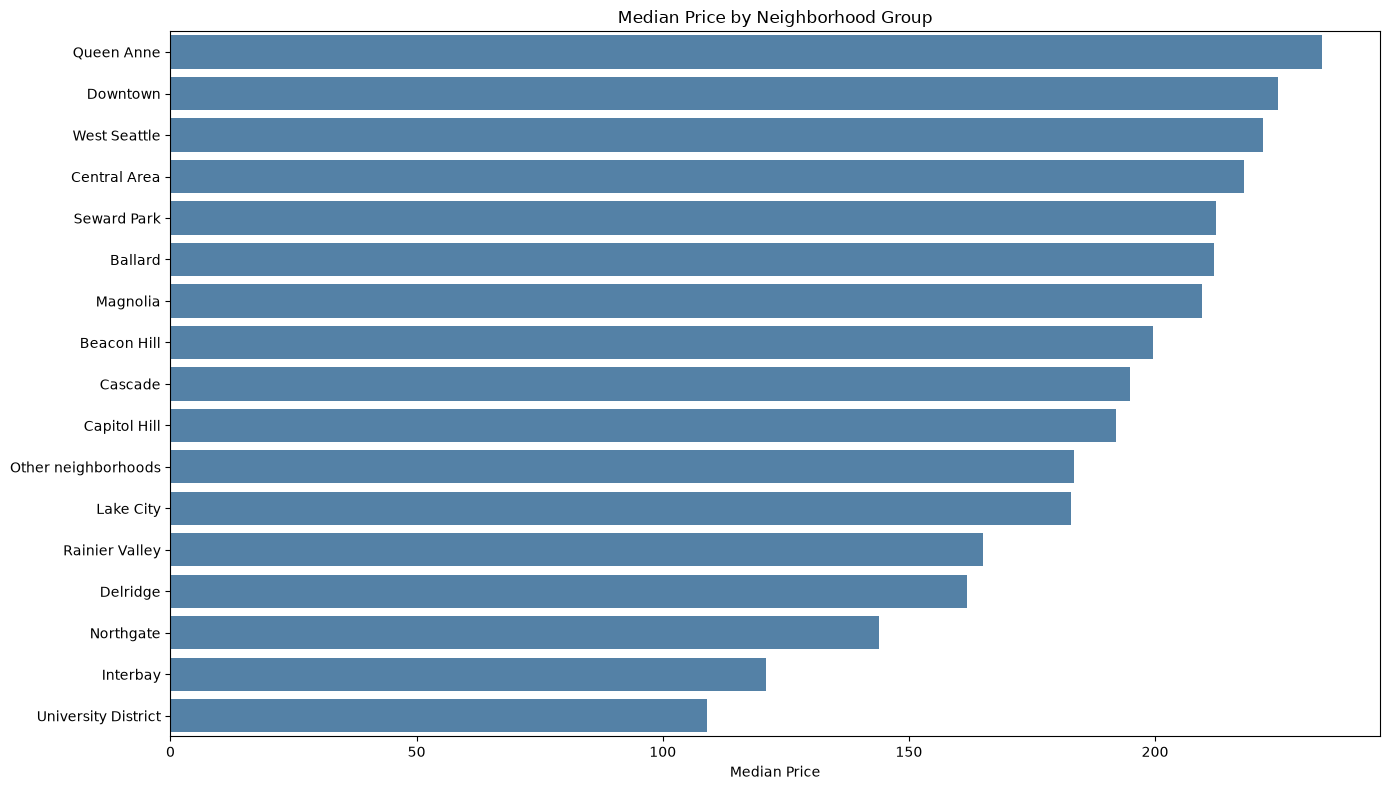

In [21]:
neighbor_group_prices = (
    train_set.groupby("neighbourhood_group_cleansed").agg(
        median_price=("price", "median"),
        average_price=("price", "mean"),
        listings=("price", "count")
    ).sort_values(by='median_price',ascending=False))
viz.create_bar_plot(neighbor_group_prices,'median_price',neighbor_group_prices.index,"Median Price by Neighborhood Group",
                    "Median Price")
plt.show();

In [22]:
# macro_zone_prices = train_set.groupby('pure_spatial_cluster').agg(median_price=('price','median'),
#                     mean_price=('price','mean')).sort_values(by='median_price',ascending=False)
# viz.create_bar_plot(macro_zone_prices,'median_price',macro_zone_prices.index,"Median Airbnb Price by Cluster",
#                     "Median Airbnb Price","Macro Zone Cluster")
# plt.show();

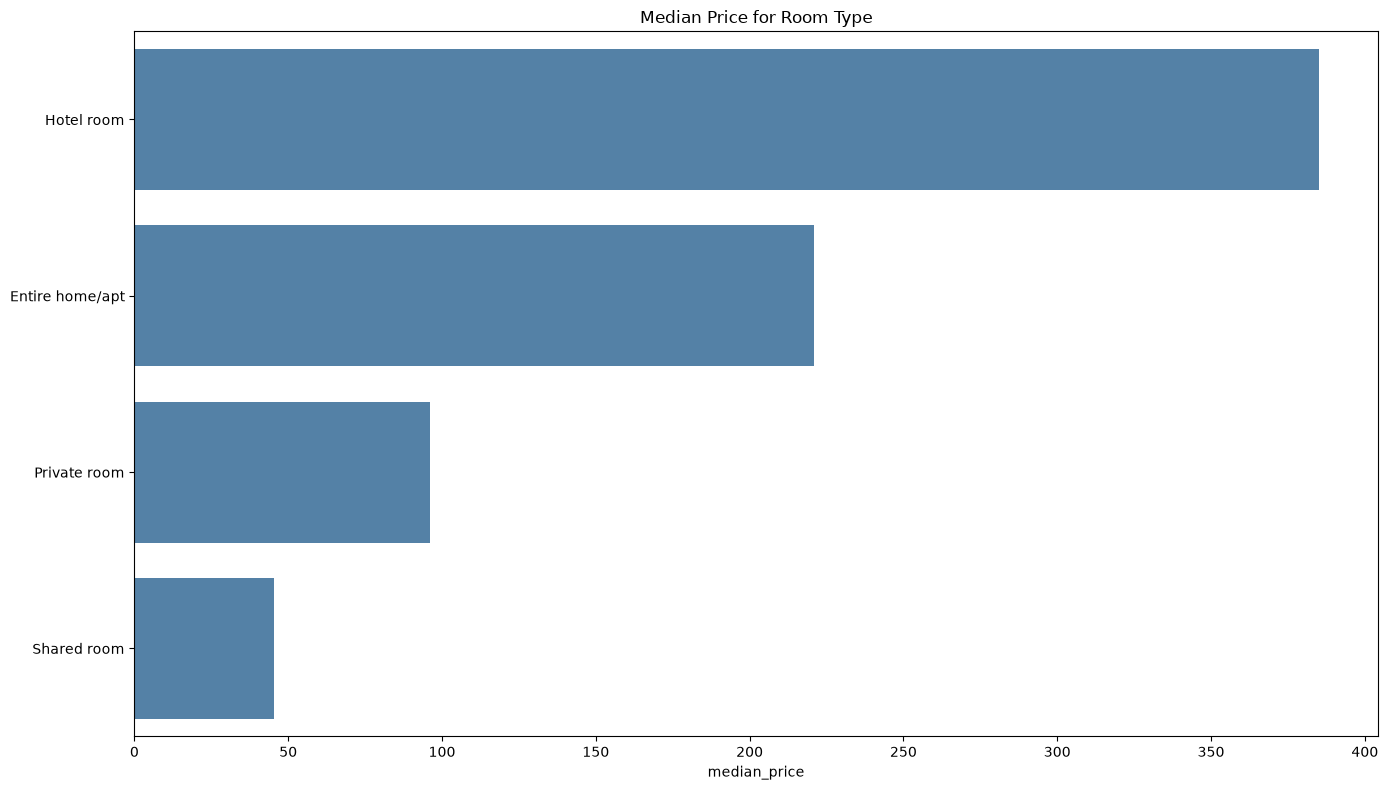

In [23]:
room_type_prices = (train_set.groupby("room_type").agg(median_price=("price", "median"),average_price=("price", "mean"),
                                                    listings=("price", "count")).sort_values(by='average_price',
                                                    ascending=False))
viz.create_bar_plot(room_type_prices,'median_price','room_type',title='Median Price for Room Type')
plt.show()

*Check distributions of several key variables*

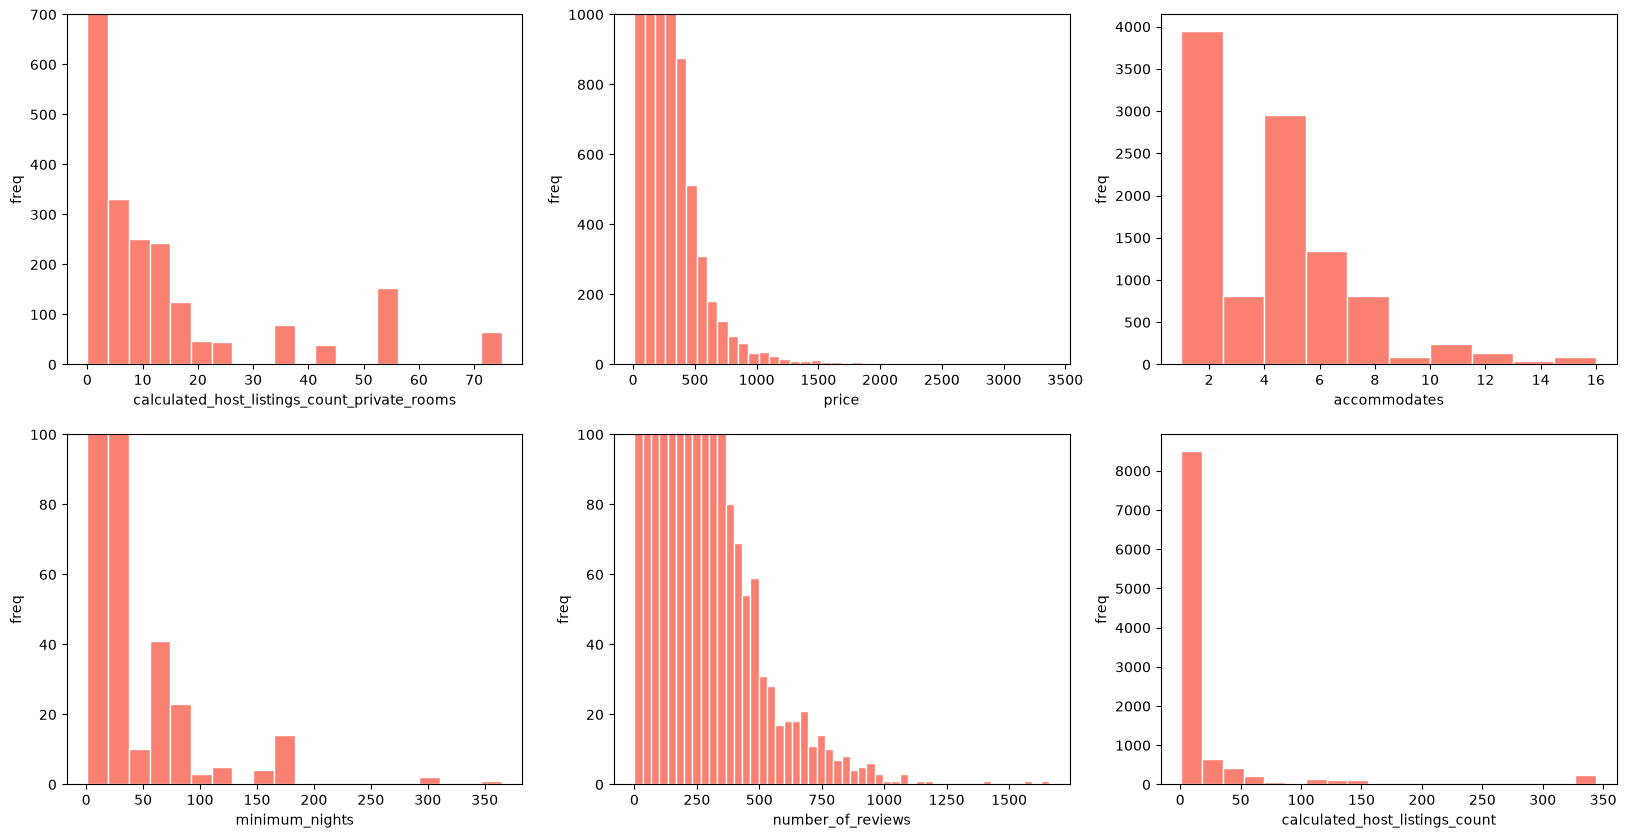

In [24]:
hist_data = ['calculated_host_listings_count_private_rooms','price','accommodates','minimum_nights',
             'number_of_reviews','calculated_host_listings_count']

viz.create_histogram(train_set,data_cols=hist_data)
plt.show();

*Histograms for key variables after log-transformation*

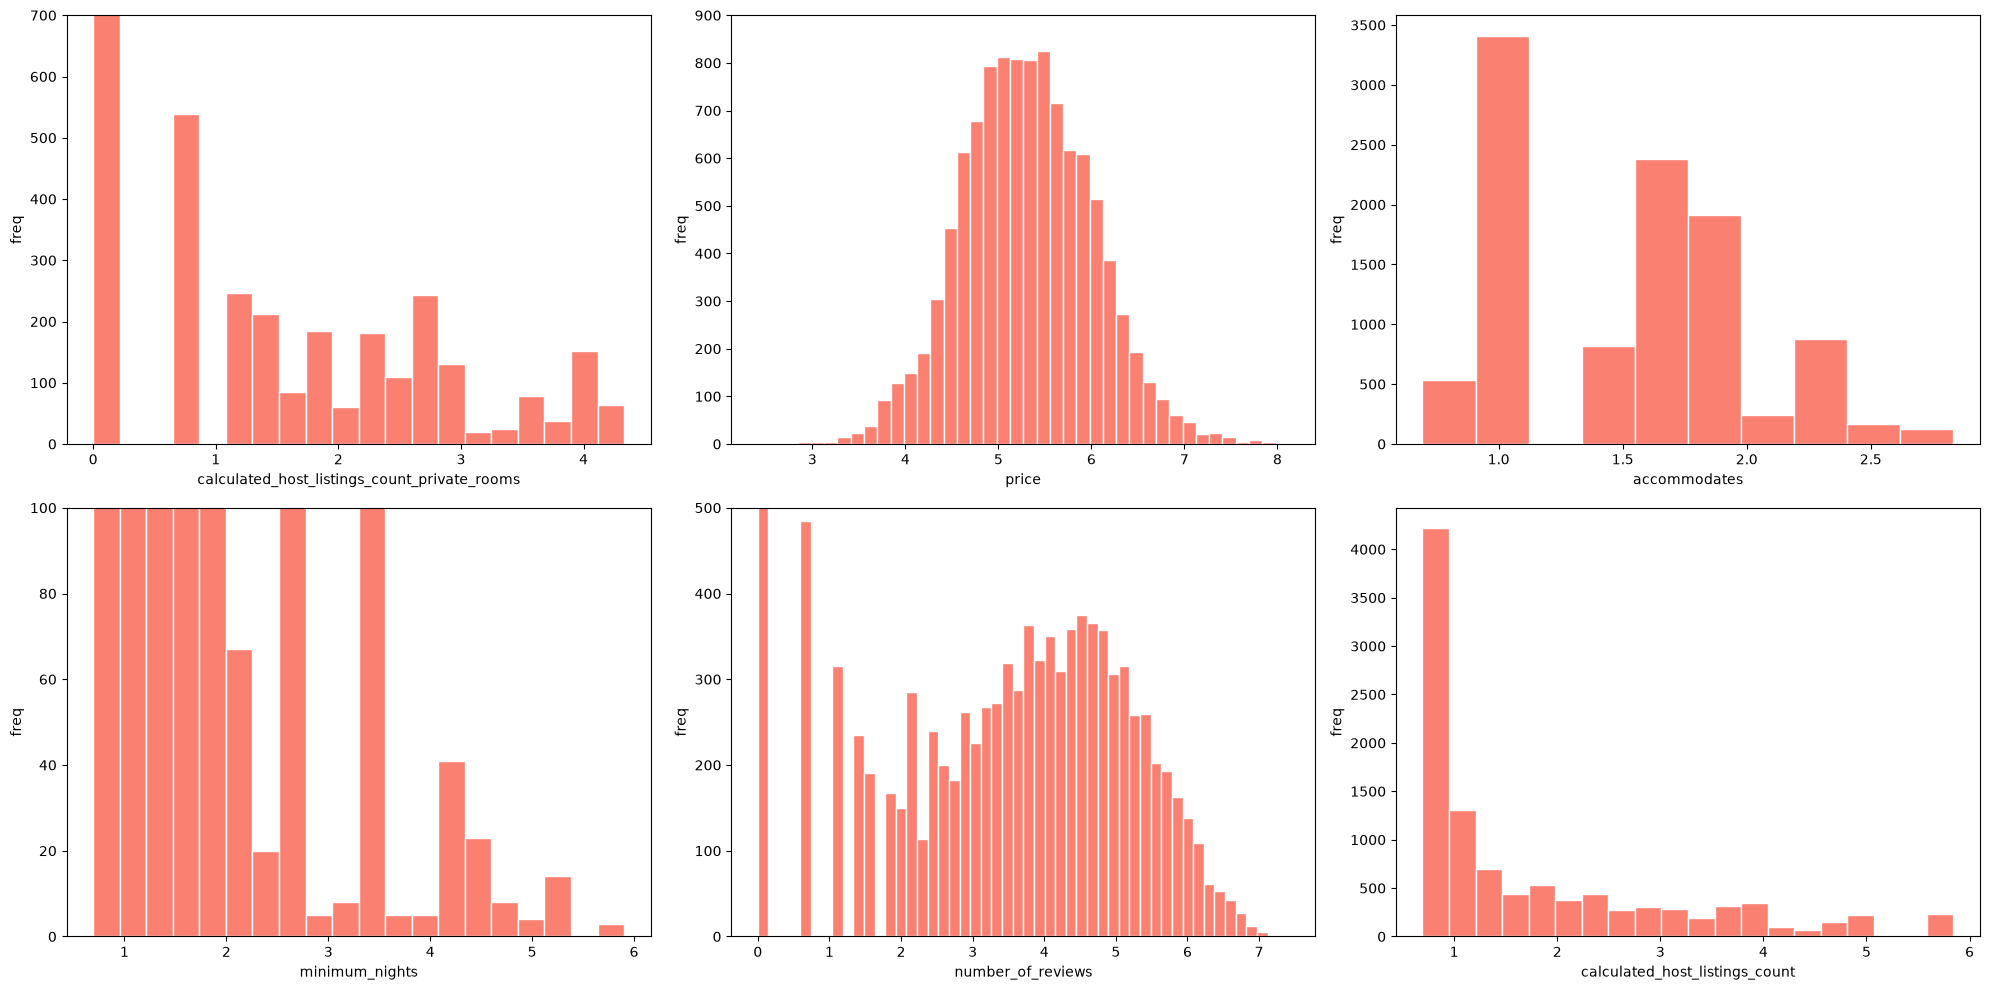

In [25]:
y_limits_hist = {0:(0,700),1:(0,900),3:(0,100),4:(0,500)}

viz.plot_histograms(train_set,cols=hist_data,y_limits=y_limits_hist,logged=True)
plt.show();

*Boxplots showing price range information for several categories* 

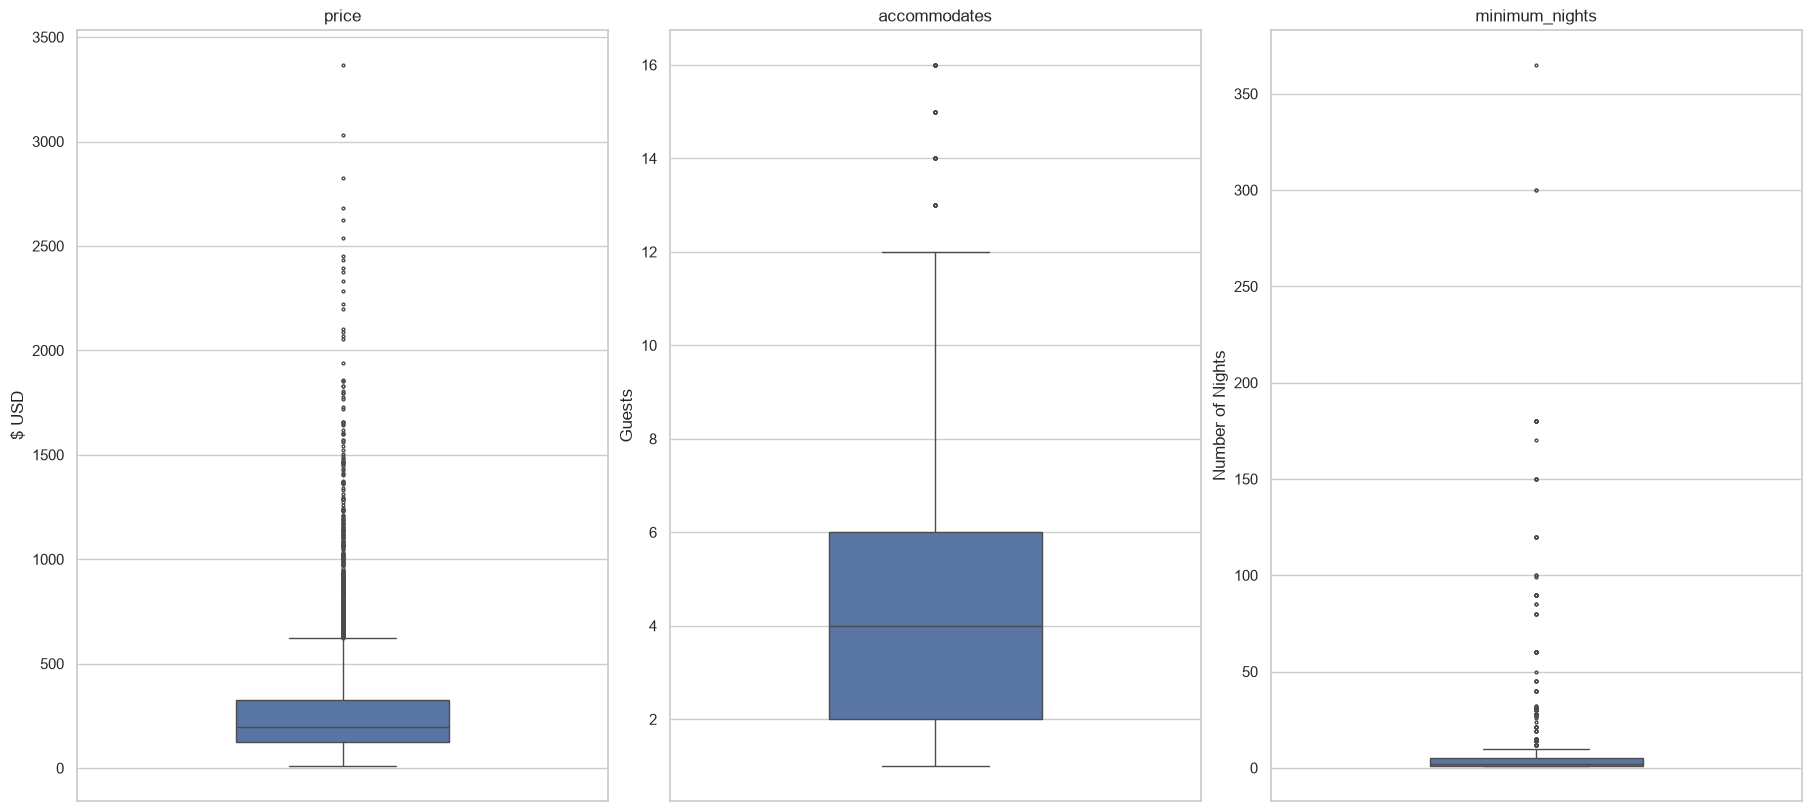

In [26]:
box_list = ['price','accommodates','minimum_nights']
y_label_list = ['$ USD','Guests','Number of Nights']
viz.plot_boxplots(train_set,box_list,y_label_list)
plt.show();

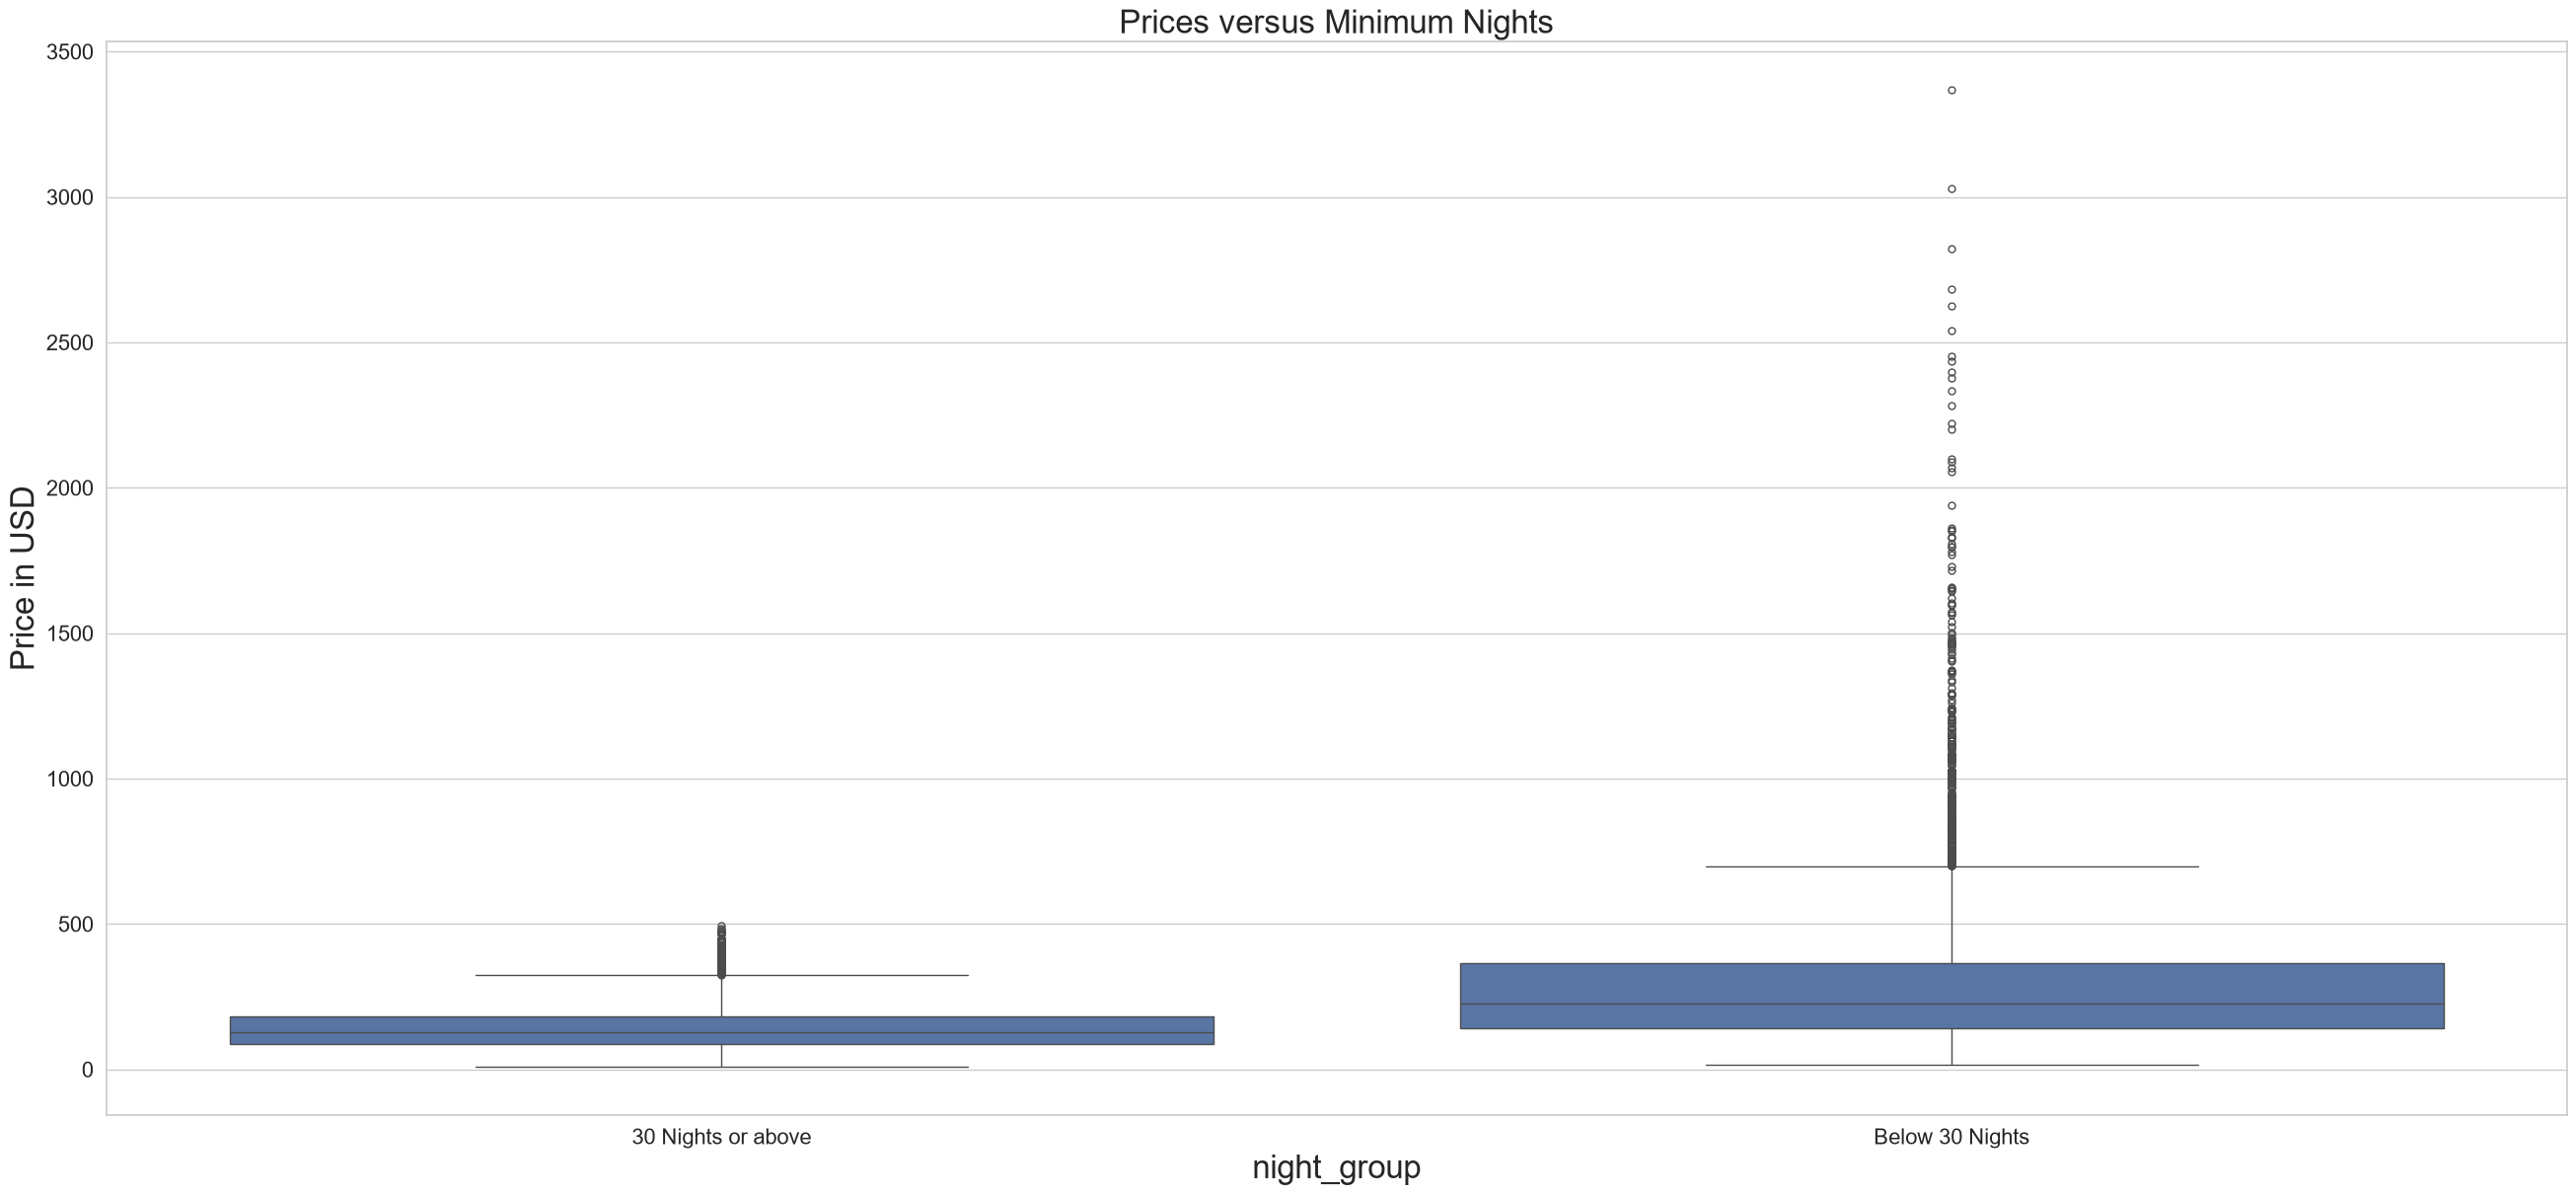

In [27]:
mask_nights = (train_set['minimum_nights'] >= 30)
mapped_nights = mask_nights.map({True: "30 Nights or above", False: "Below 30 Nights"})
viz.plot_boxplot_one_fig(df=train_set.assign(night_group = mapped_nights),col='price',bins="night_group",
                         y_label="Price in USD",title="Prices versus Minimum Nights")
plt.show();

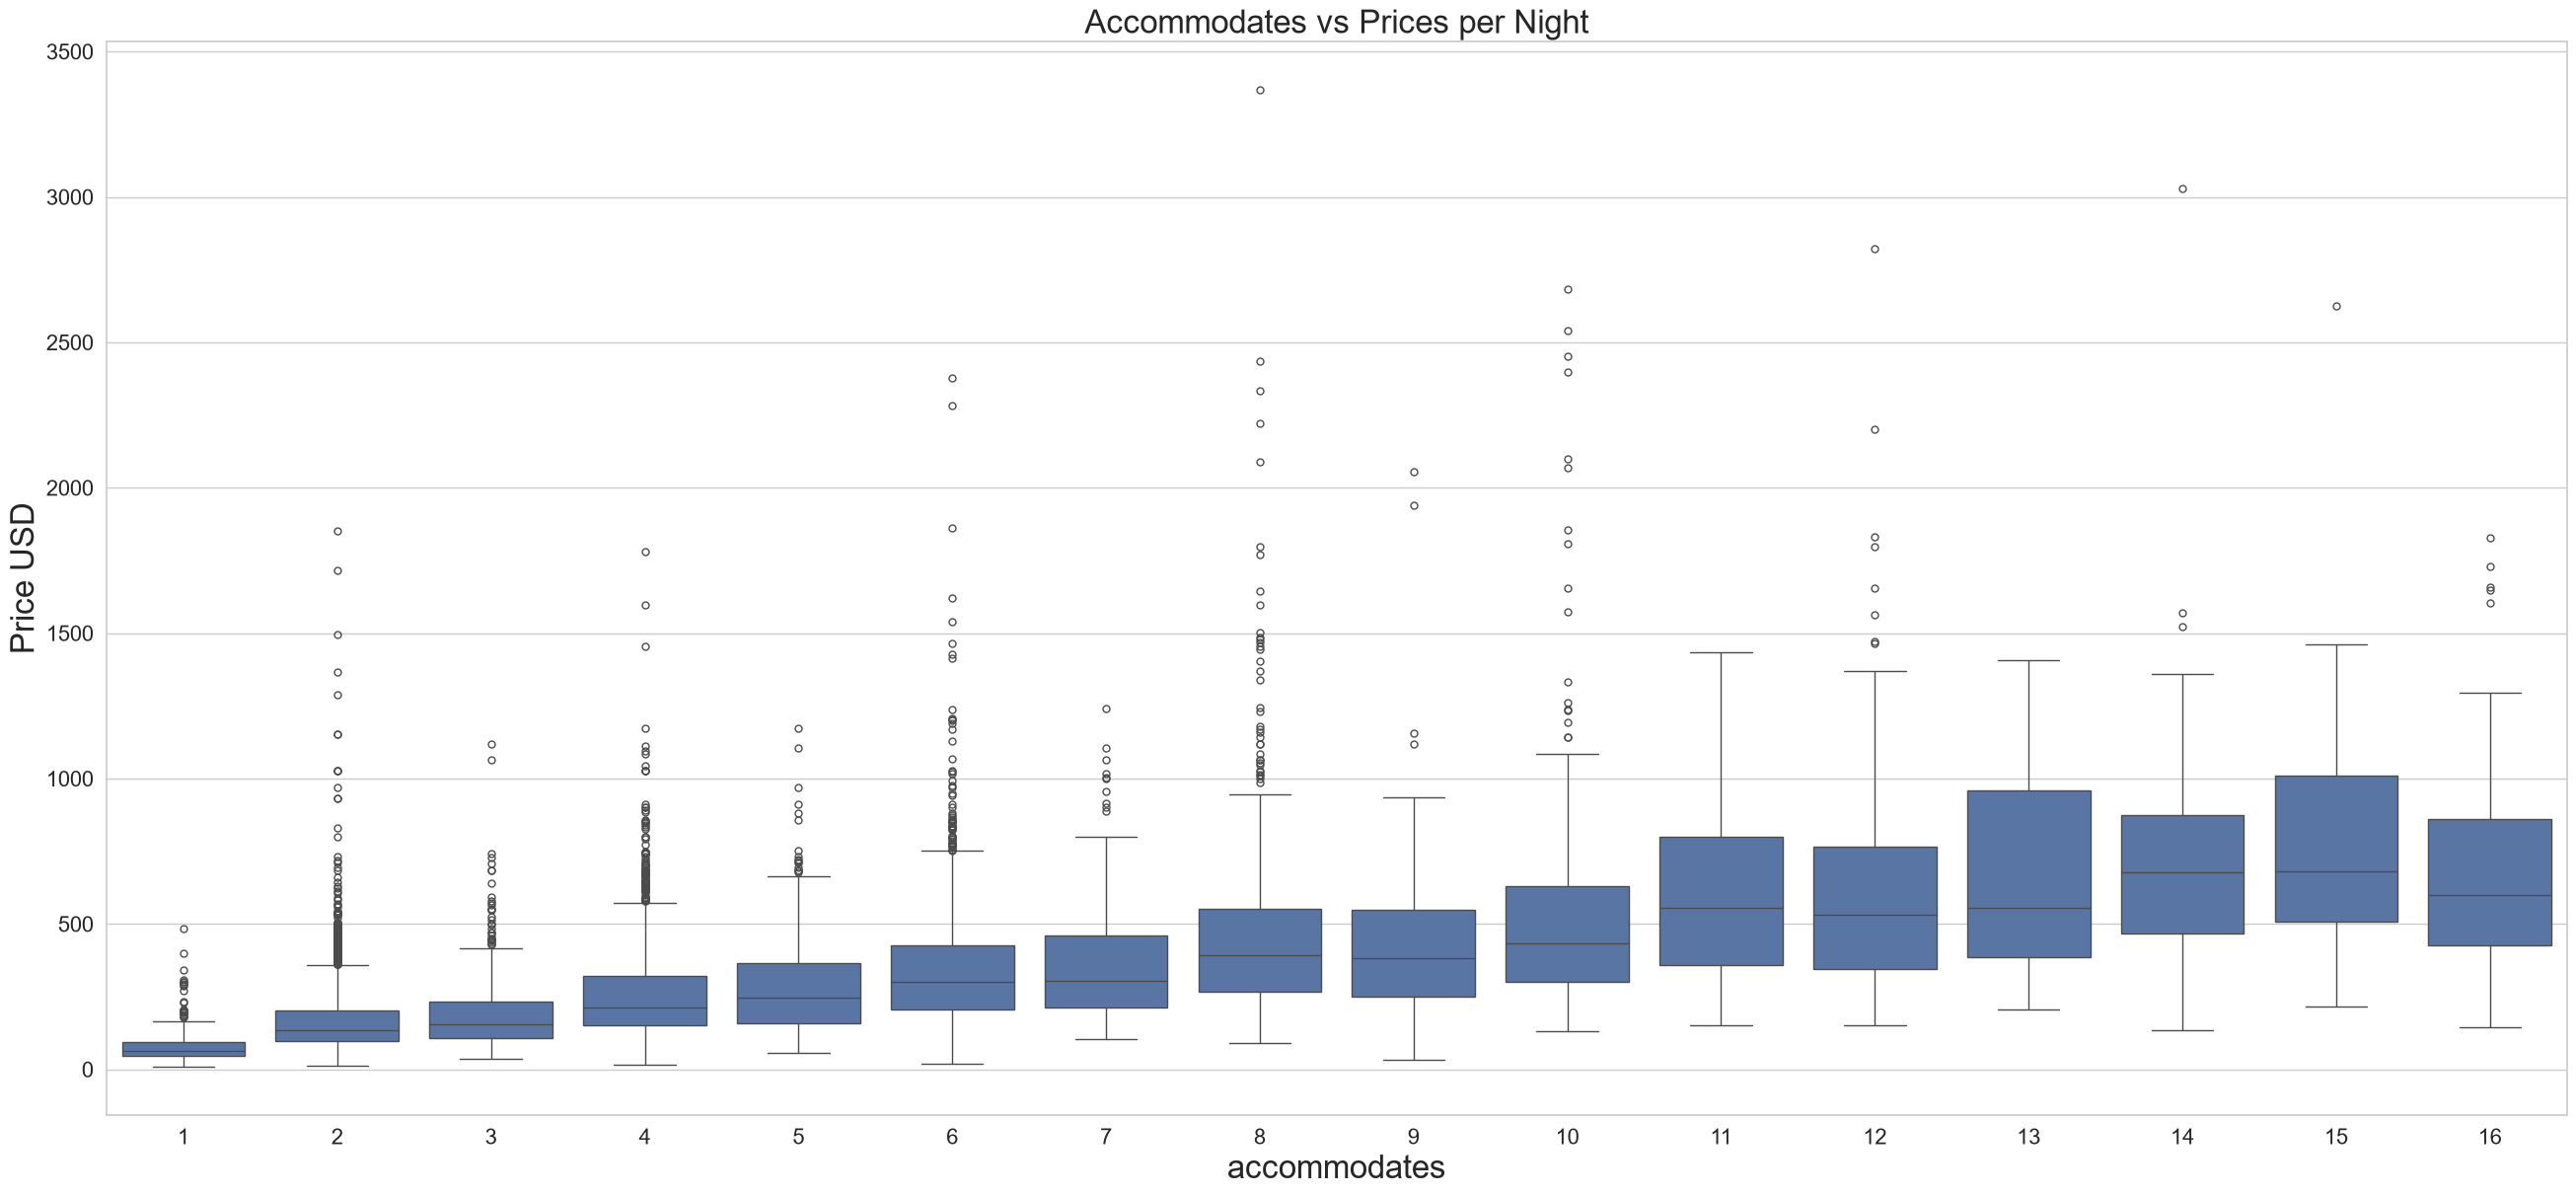

In [28]:
viz.plot_boxplot_one_fig(train_set,col='price',bins='accommodates',y_label="Price USD",
                         title= "Accommodates vs Prices per Night")
plt.show();

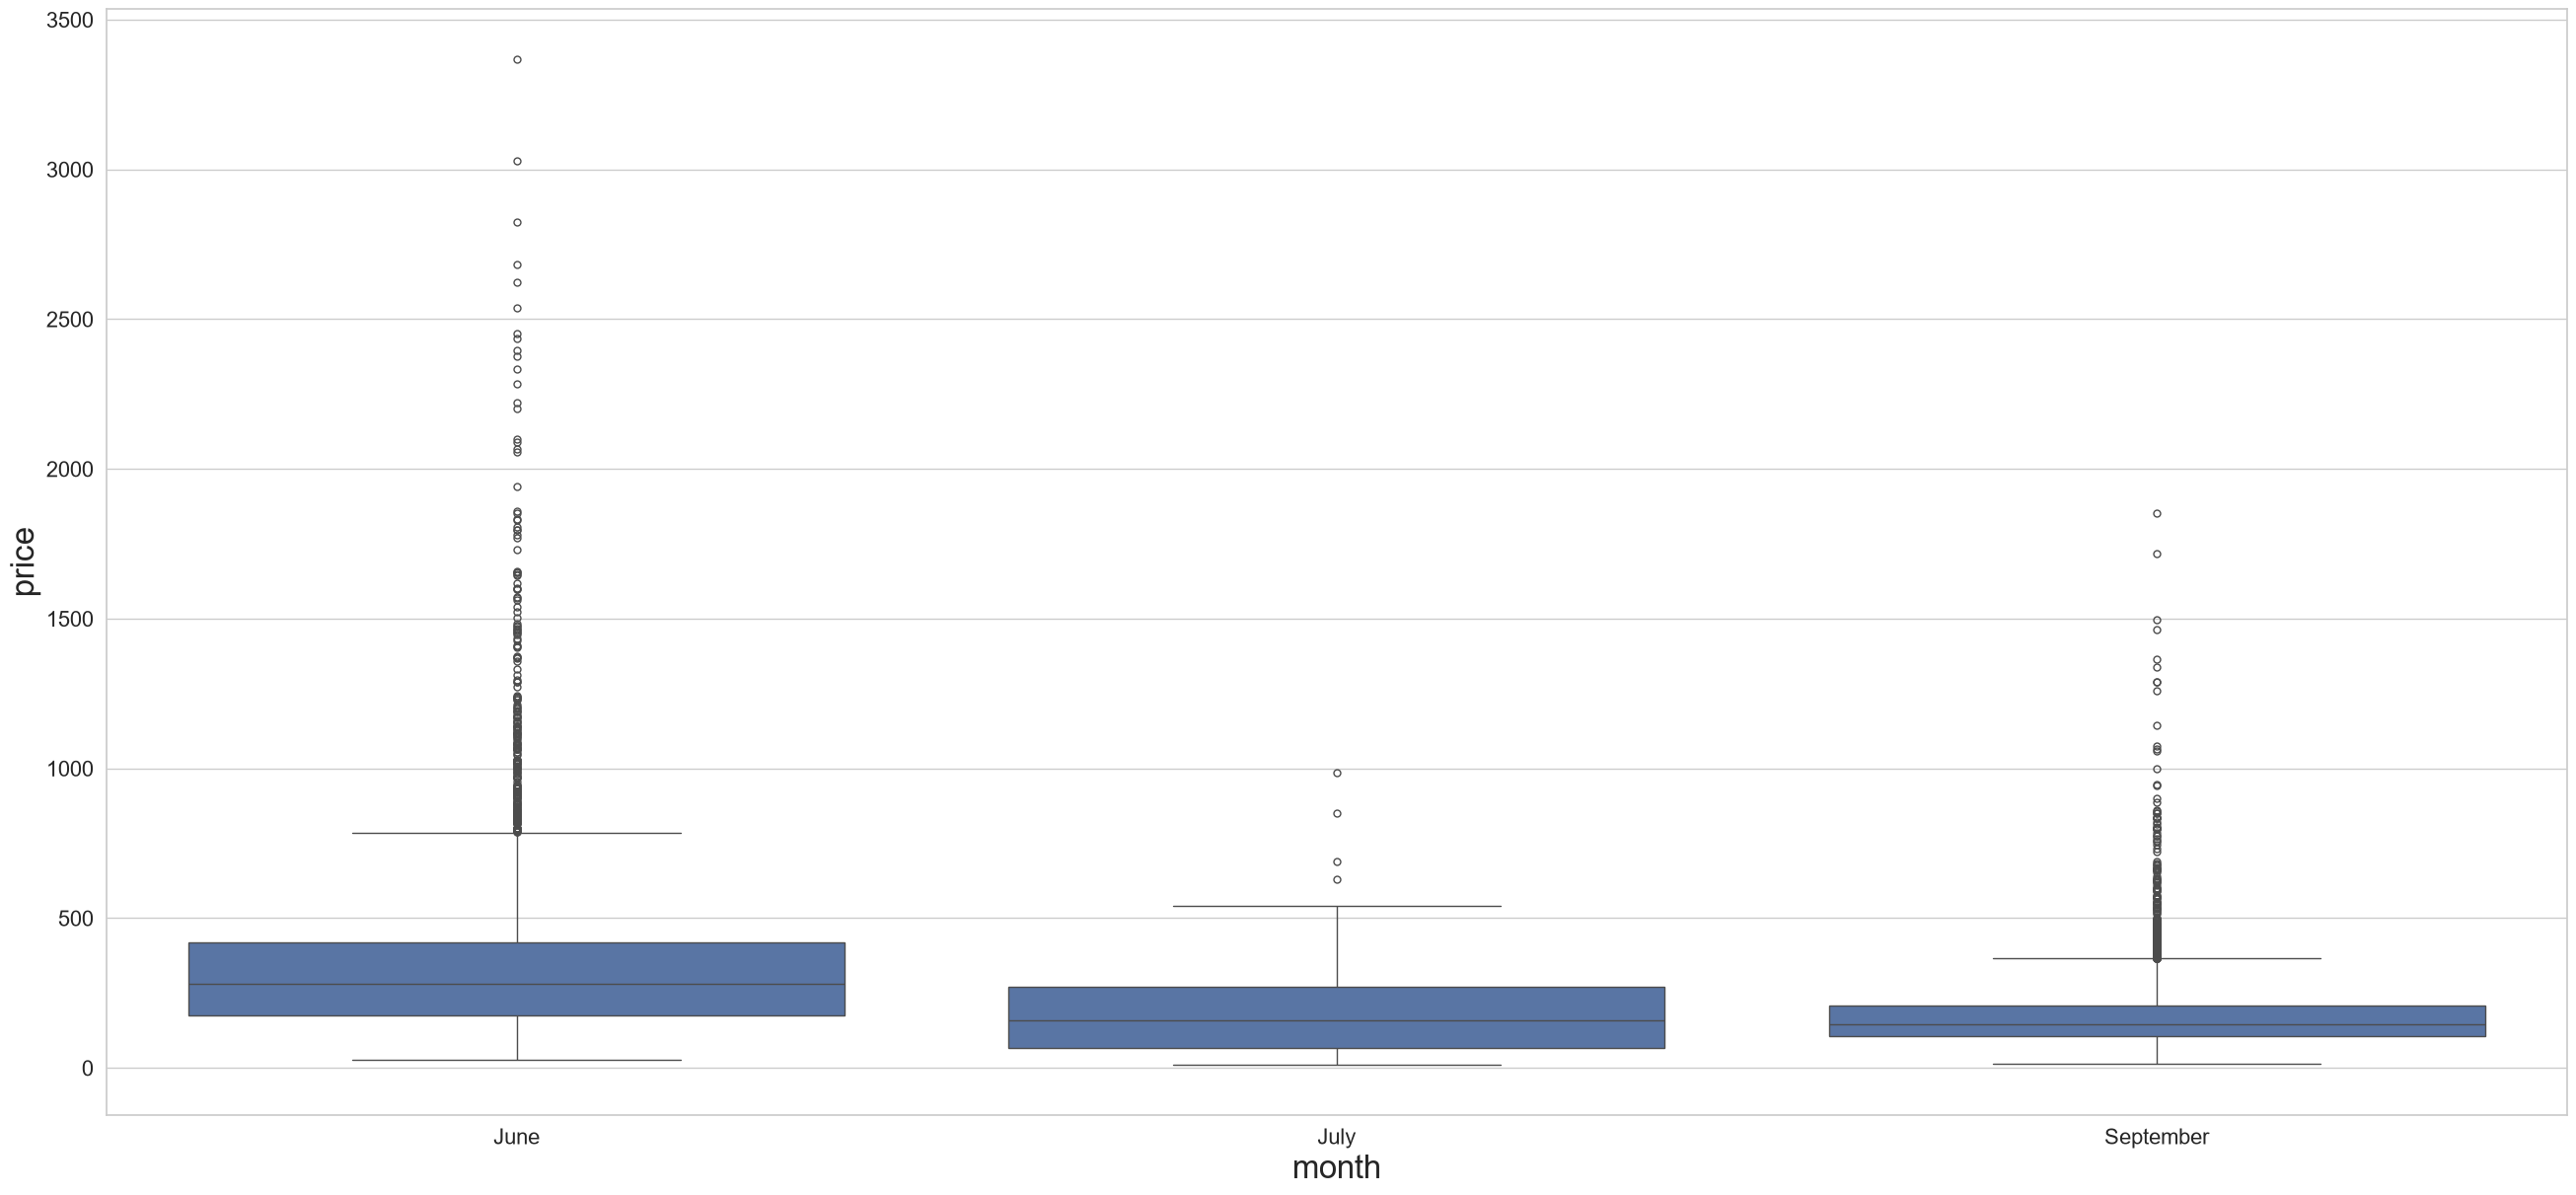

In [29]:
order = train_set.groupby("month")["price"].median().sort_values(ascending=False).index
x_bins = train_set['month']

viz.plot_boxplot_one_fig(train_set,col='price',bins='month',x_axis_order=order)
plt.show()

*Correlation heatmaps*

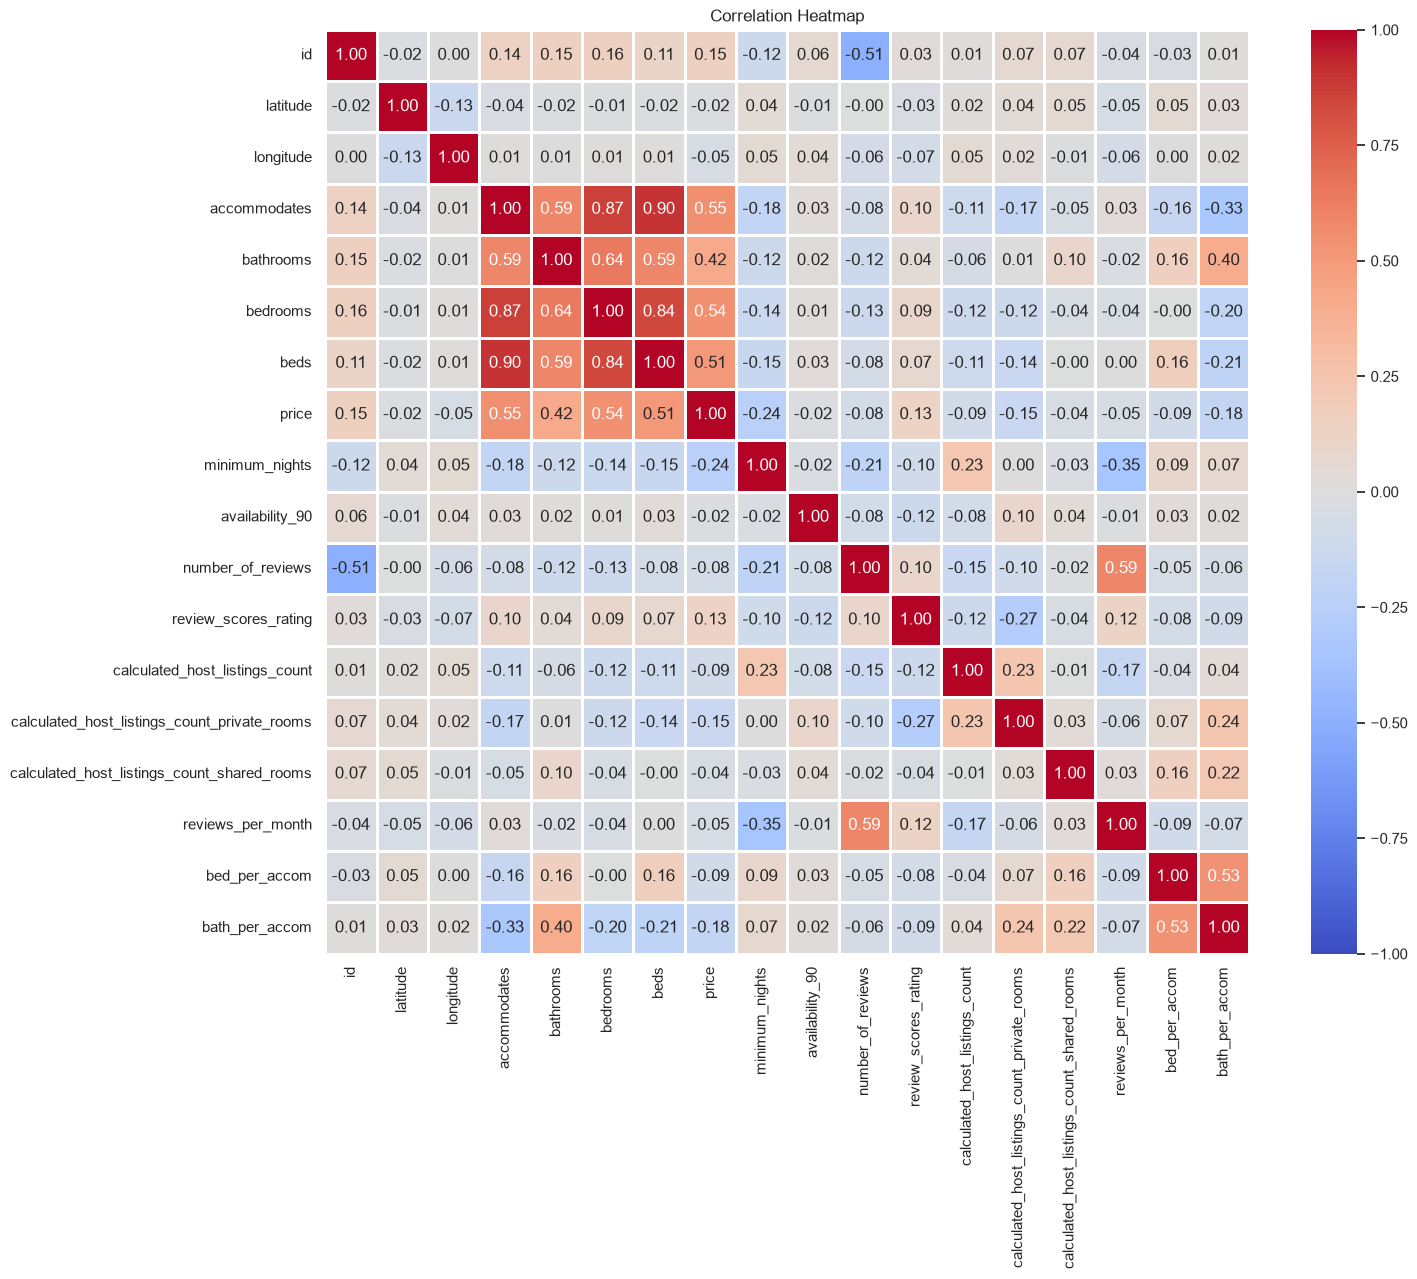

In [30]:
corr = train_set.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, linewidths=1)
plt.title('Correlation Heatmap')
plt.show()

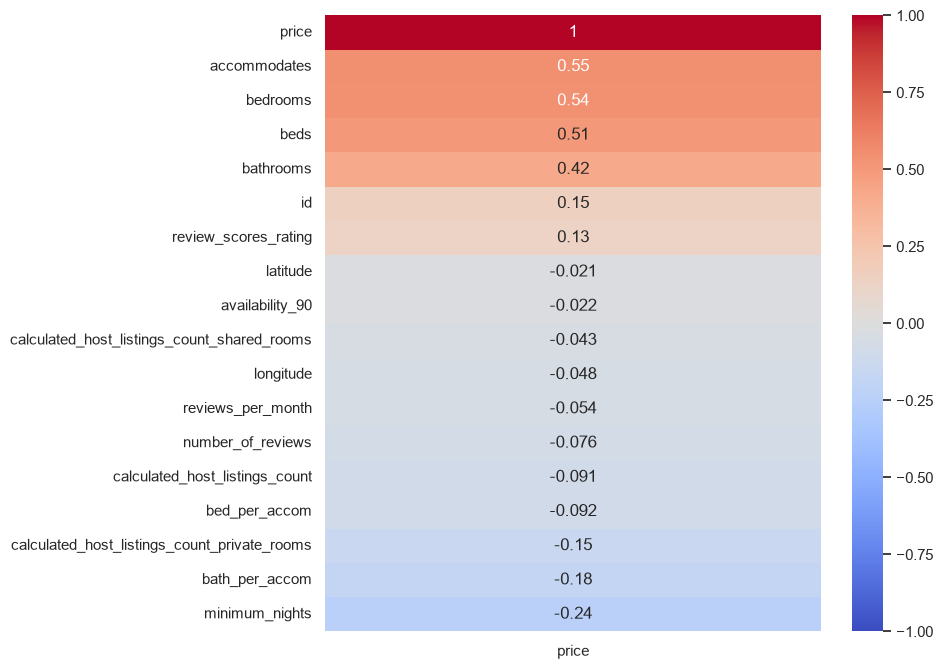

In [31]:
corr_df = corr[['price']].sort_values(by='price', ascending=False)

plt.figure(figsize=(8, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.show();

*Scatter plots comparing key features and price*

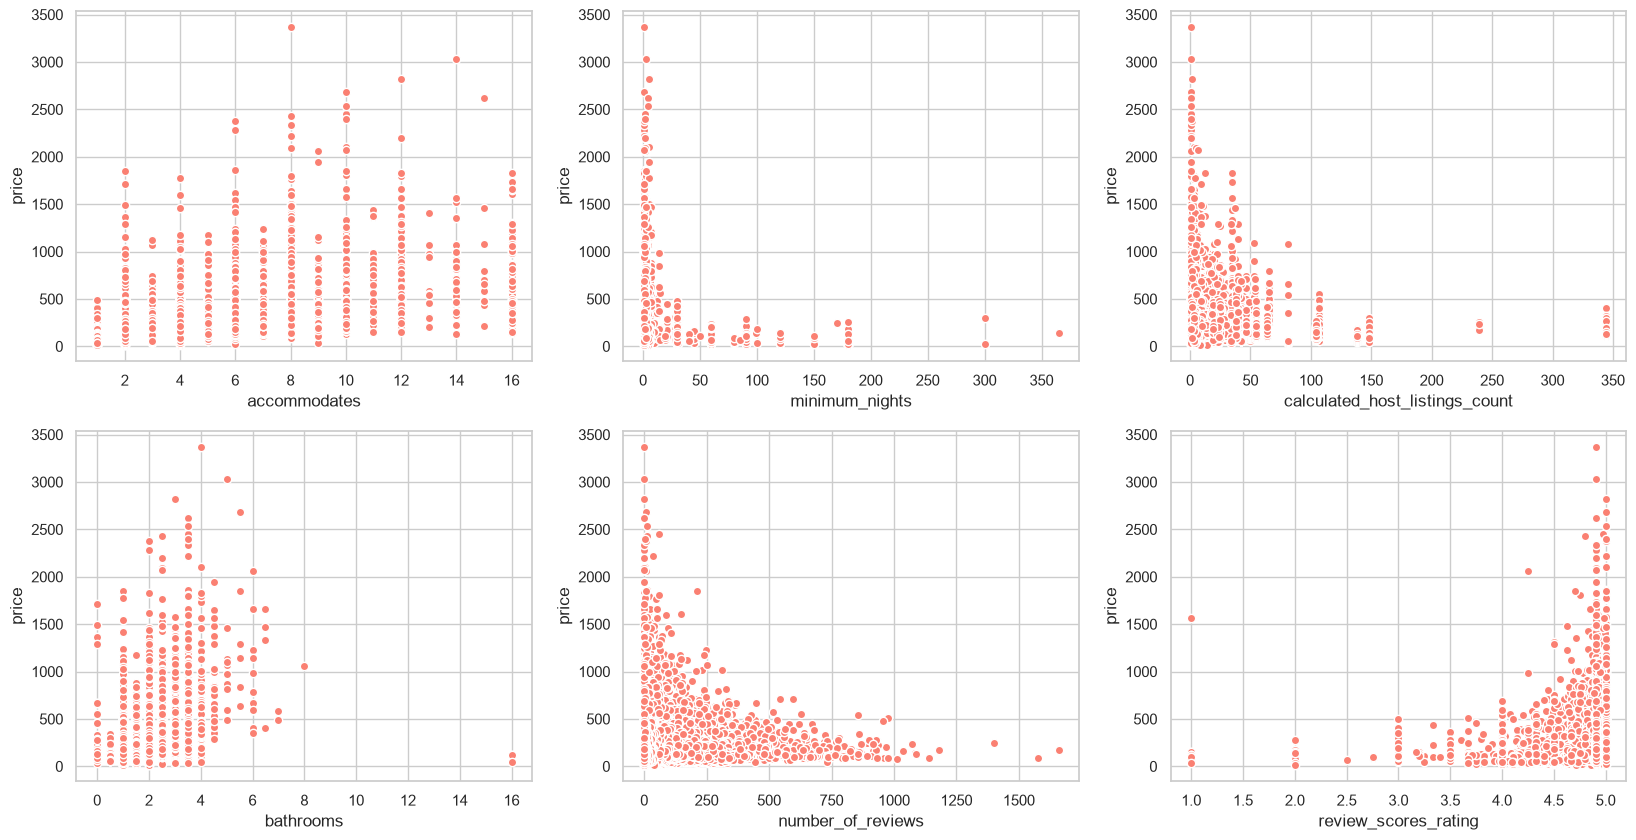

In [32]:
x_lables = ['accommodates','minimum_nights','calculated_host_listings_count','bathrooms','number_of_reviews',
            'review_scores_rating']
y_label = ['price','price','price','price','price','price']

viz.make_scatter_plots(train_set,x_vars=x_lables,y_vars=y_label)
plt.show();

*Evaluate and extract amenities that may affect price*

In [33]:
high_price_amen = train_set[train_set['price'] > 500]['amenities'].apply(ast.literal_eval)
high_price_amen_count = high_price_amen.explode().value_counts()
mid_price_amen = train_set[train_set['price'] <=500]['amenities'].apply(ast.literal_eval)
mid_price_amen_count = mid_price_amen.explode().value_counts()

high_price_amen_count_uniq = high_price_amen_count[~high_price_amen_count.index.isin(mid_price_amen_count.index)]
high_price_amen_count

amenities
Smoke alarm                              982
Carbon monoxide alarm                    954
Kitchen                                  948
Wifi                                     890
Hot water                                883
                                        ... 
GE Monogram stainless steel gas stove      1
Tresemme shampoo                           1
Nexus shampoo                              1
Nexus conditioner                          1
Nexus body soap                            1
Name: count, Length: 1083, dtype: int64

In [34]:
train_set = dpr.extract_amenities(train_set)

In [35]:
amenities_analy = train_set.groupby(['hot_tub','ac','patio_balcony','life_size_games']).agg(median_price = ('price','median'),
                    mean_price = ('price','mean')).sort_values(by='mean_price', ascending=False).reset_index()
amenities_analy

,hot_tub,ac,patio_balcony,life_size_games,median_price,mean_price
0,0,1,1,1,405.00,514.166970
1,1,1,1,1,430.00,416.047143
2,0,0,1,1,343.00,400.972857
3,1,1,0,1,398.27,398.270000
4,1,1,1,0,290.70,393.257568
5,1,1,0,0,270.00,381.499669
6,0,1,0,1,332.00,353.872000
7,1,0,1,0,263.00,319.333355
8,0,1,1,0,246.00,312.035521
9,1,0,1,1,270.50,270.500000


*More feature engineering. Transforming some numeric features into categorical features. Condensing property types*

In [36]:
train_set = dpr.bin_min_nights(train_set)

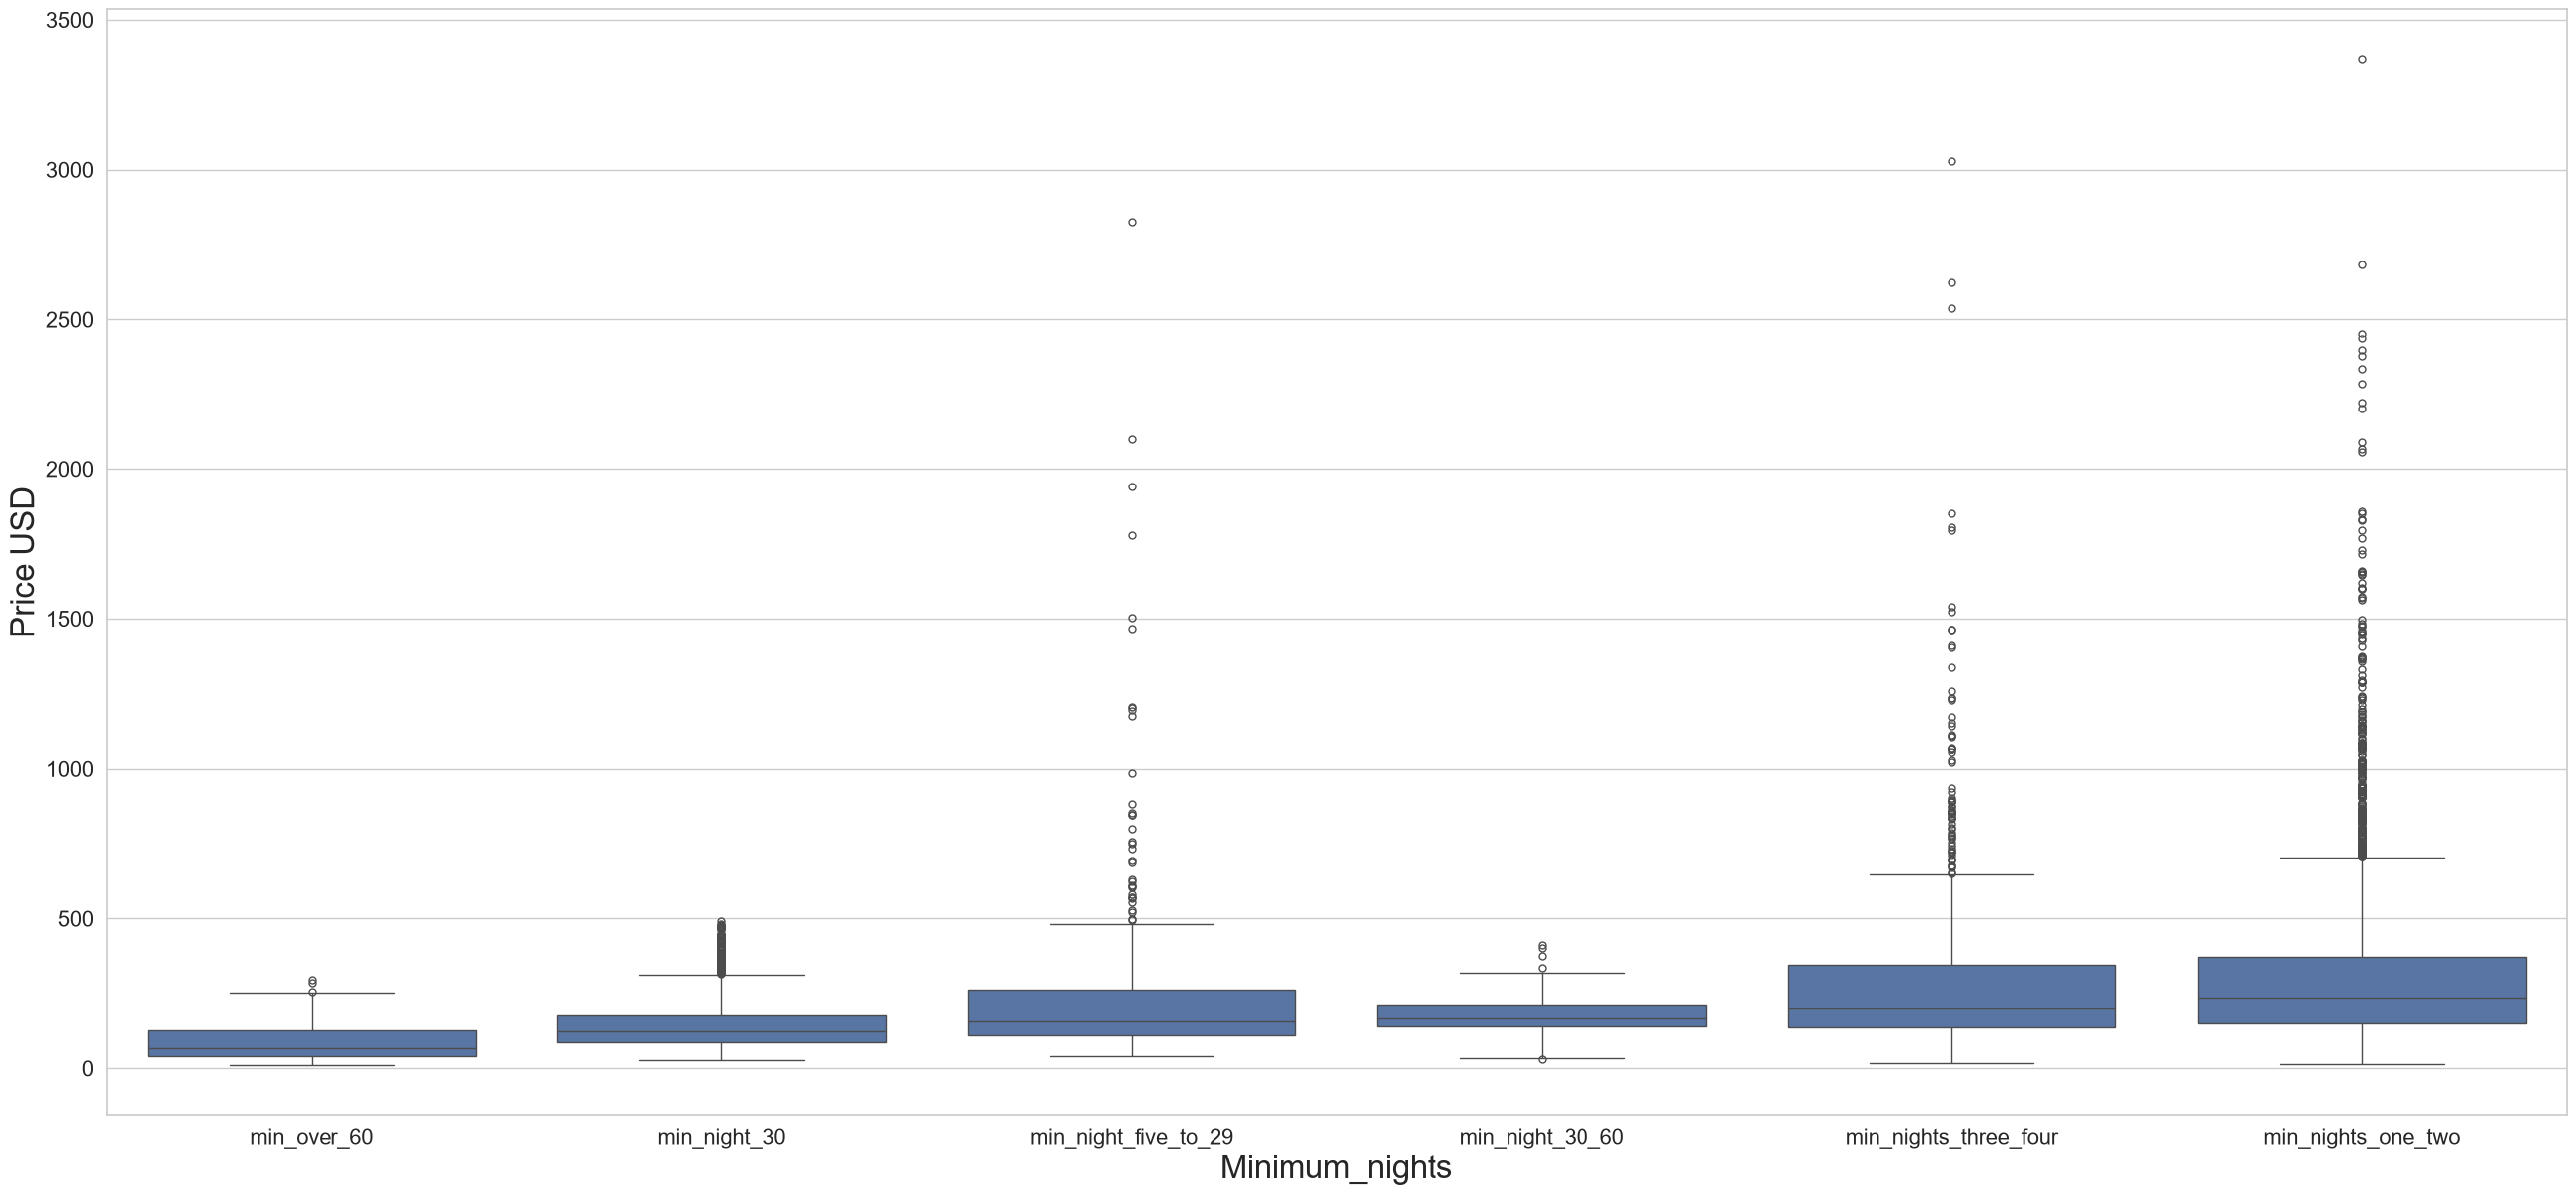

In [37]:
order = train_set.groupby(by=["minimum_nights_cat"])["price"].median().sort_values().index
viz.plot_boxplot_one_fig(train_set,col='price',bins='minimum_nights_cat',x_axis_order=order,y_label='Price USD',x_label='Minimum_nights')
plt.show();

In [38]:
train_set = dpr.bin_accommodates(train_set)

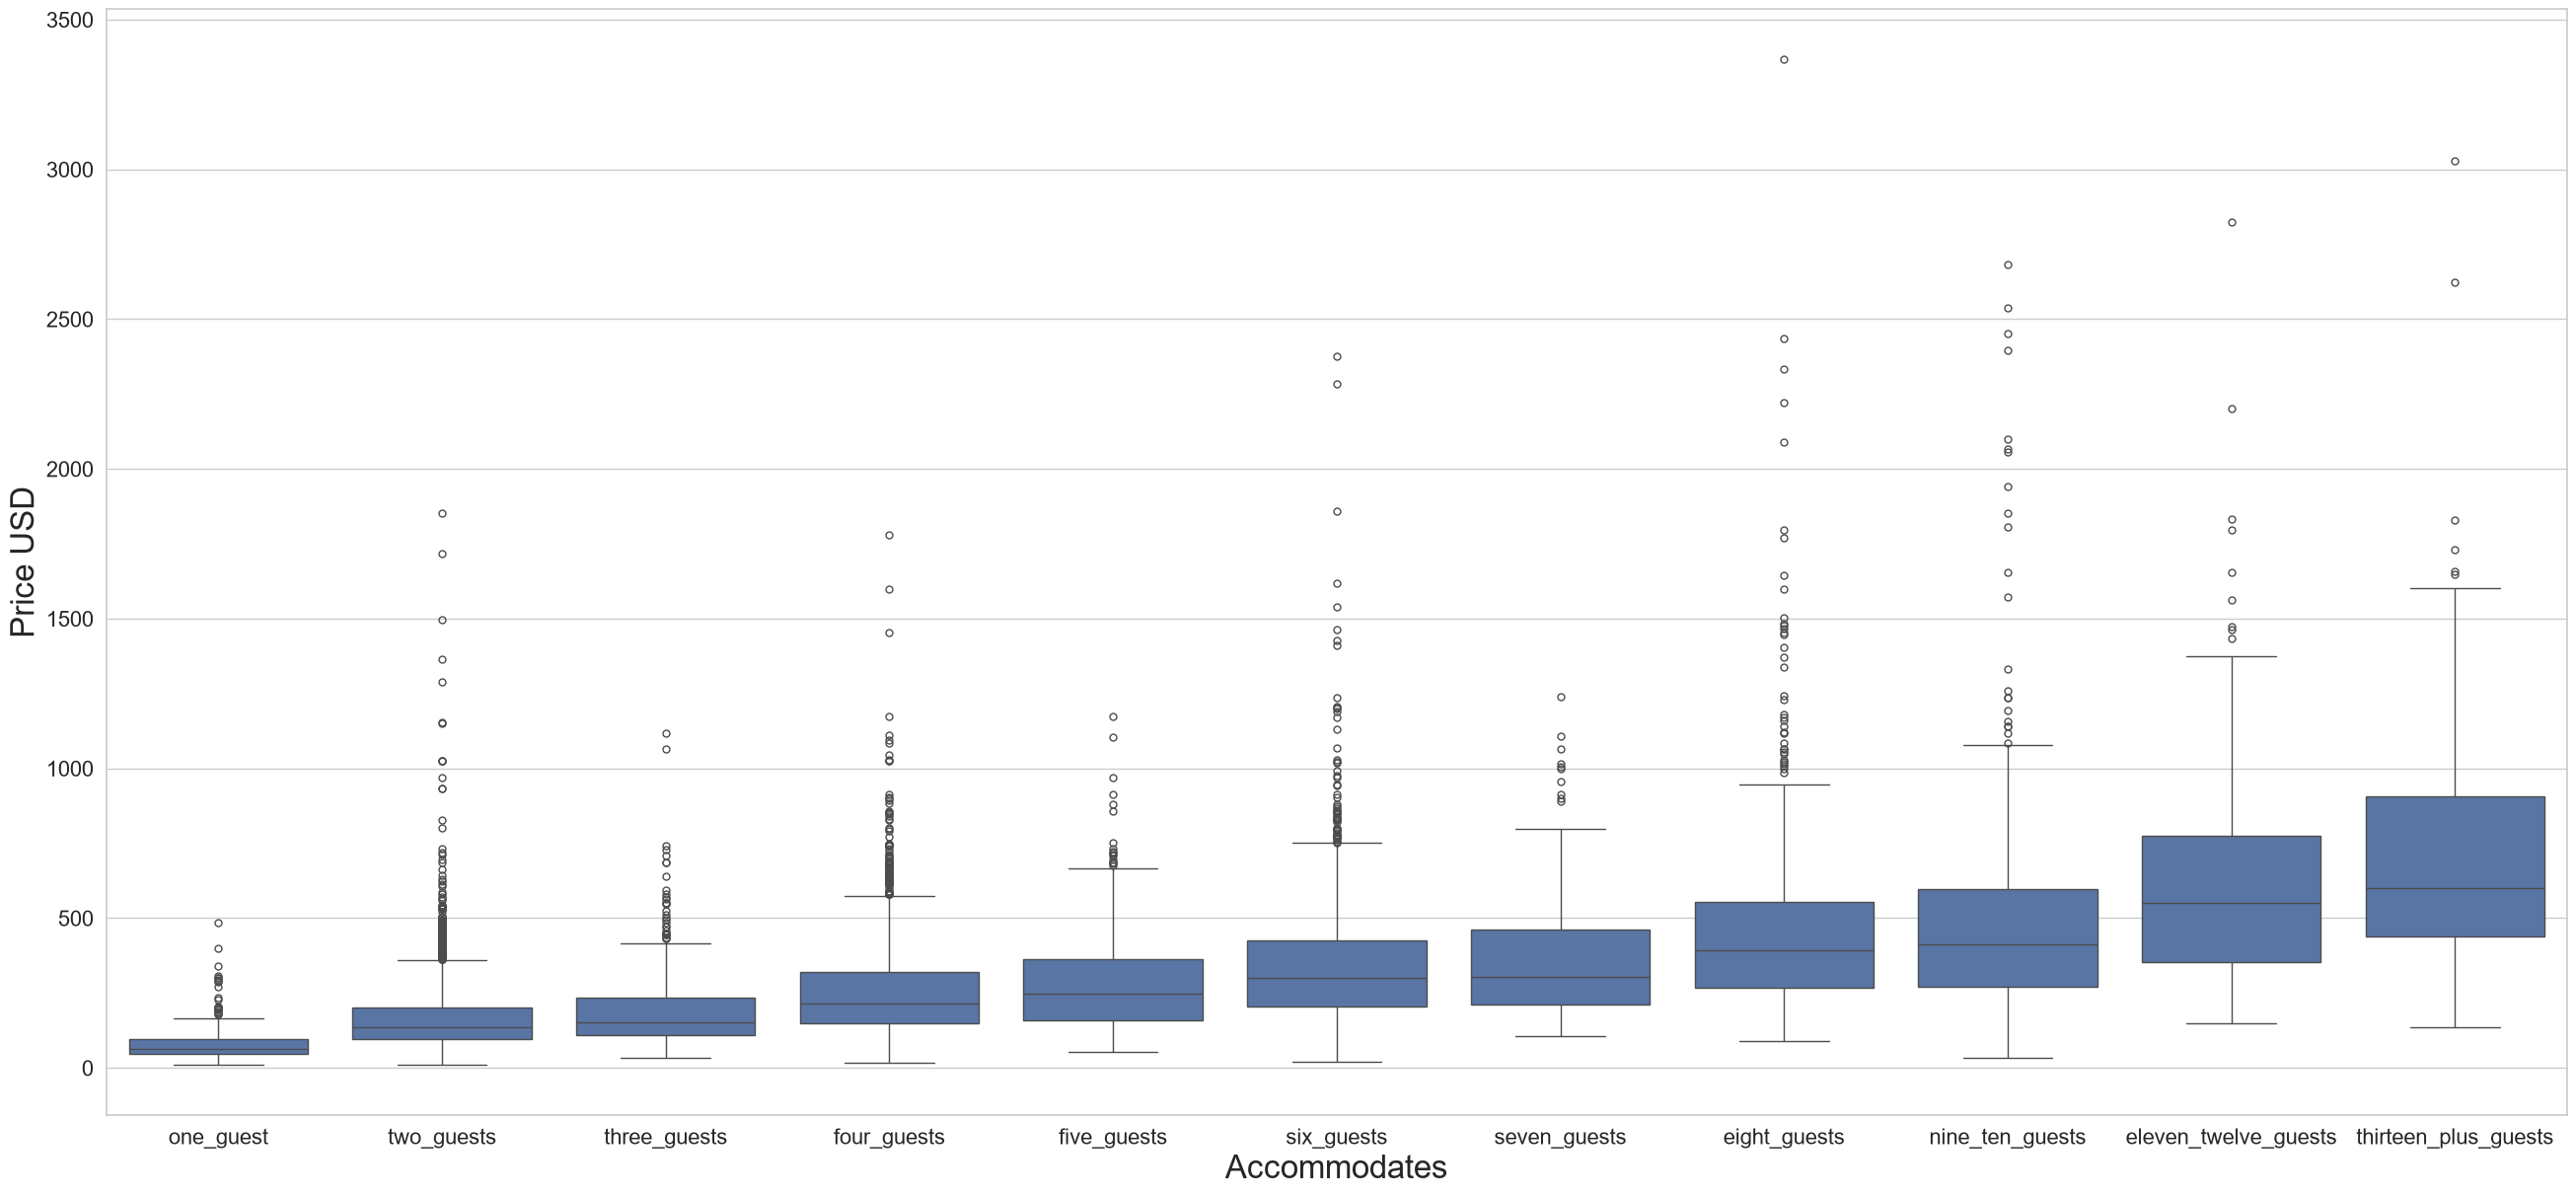

In [39]:
order = train_set.groupby(by=["accommodates_cat"])["price"].median().sort_values().index

viz.plot_boxplot_one_fig(train_set,col='price',bins='accommodates_cat',x_axis_order=order,y_label='Price USD',
                         x_label='Accommodates')
plt.show();

In [40]:
train_set = dpr.bin_bathrooms(train_set)

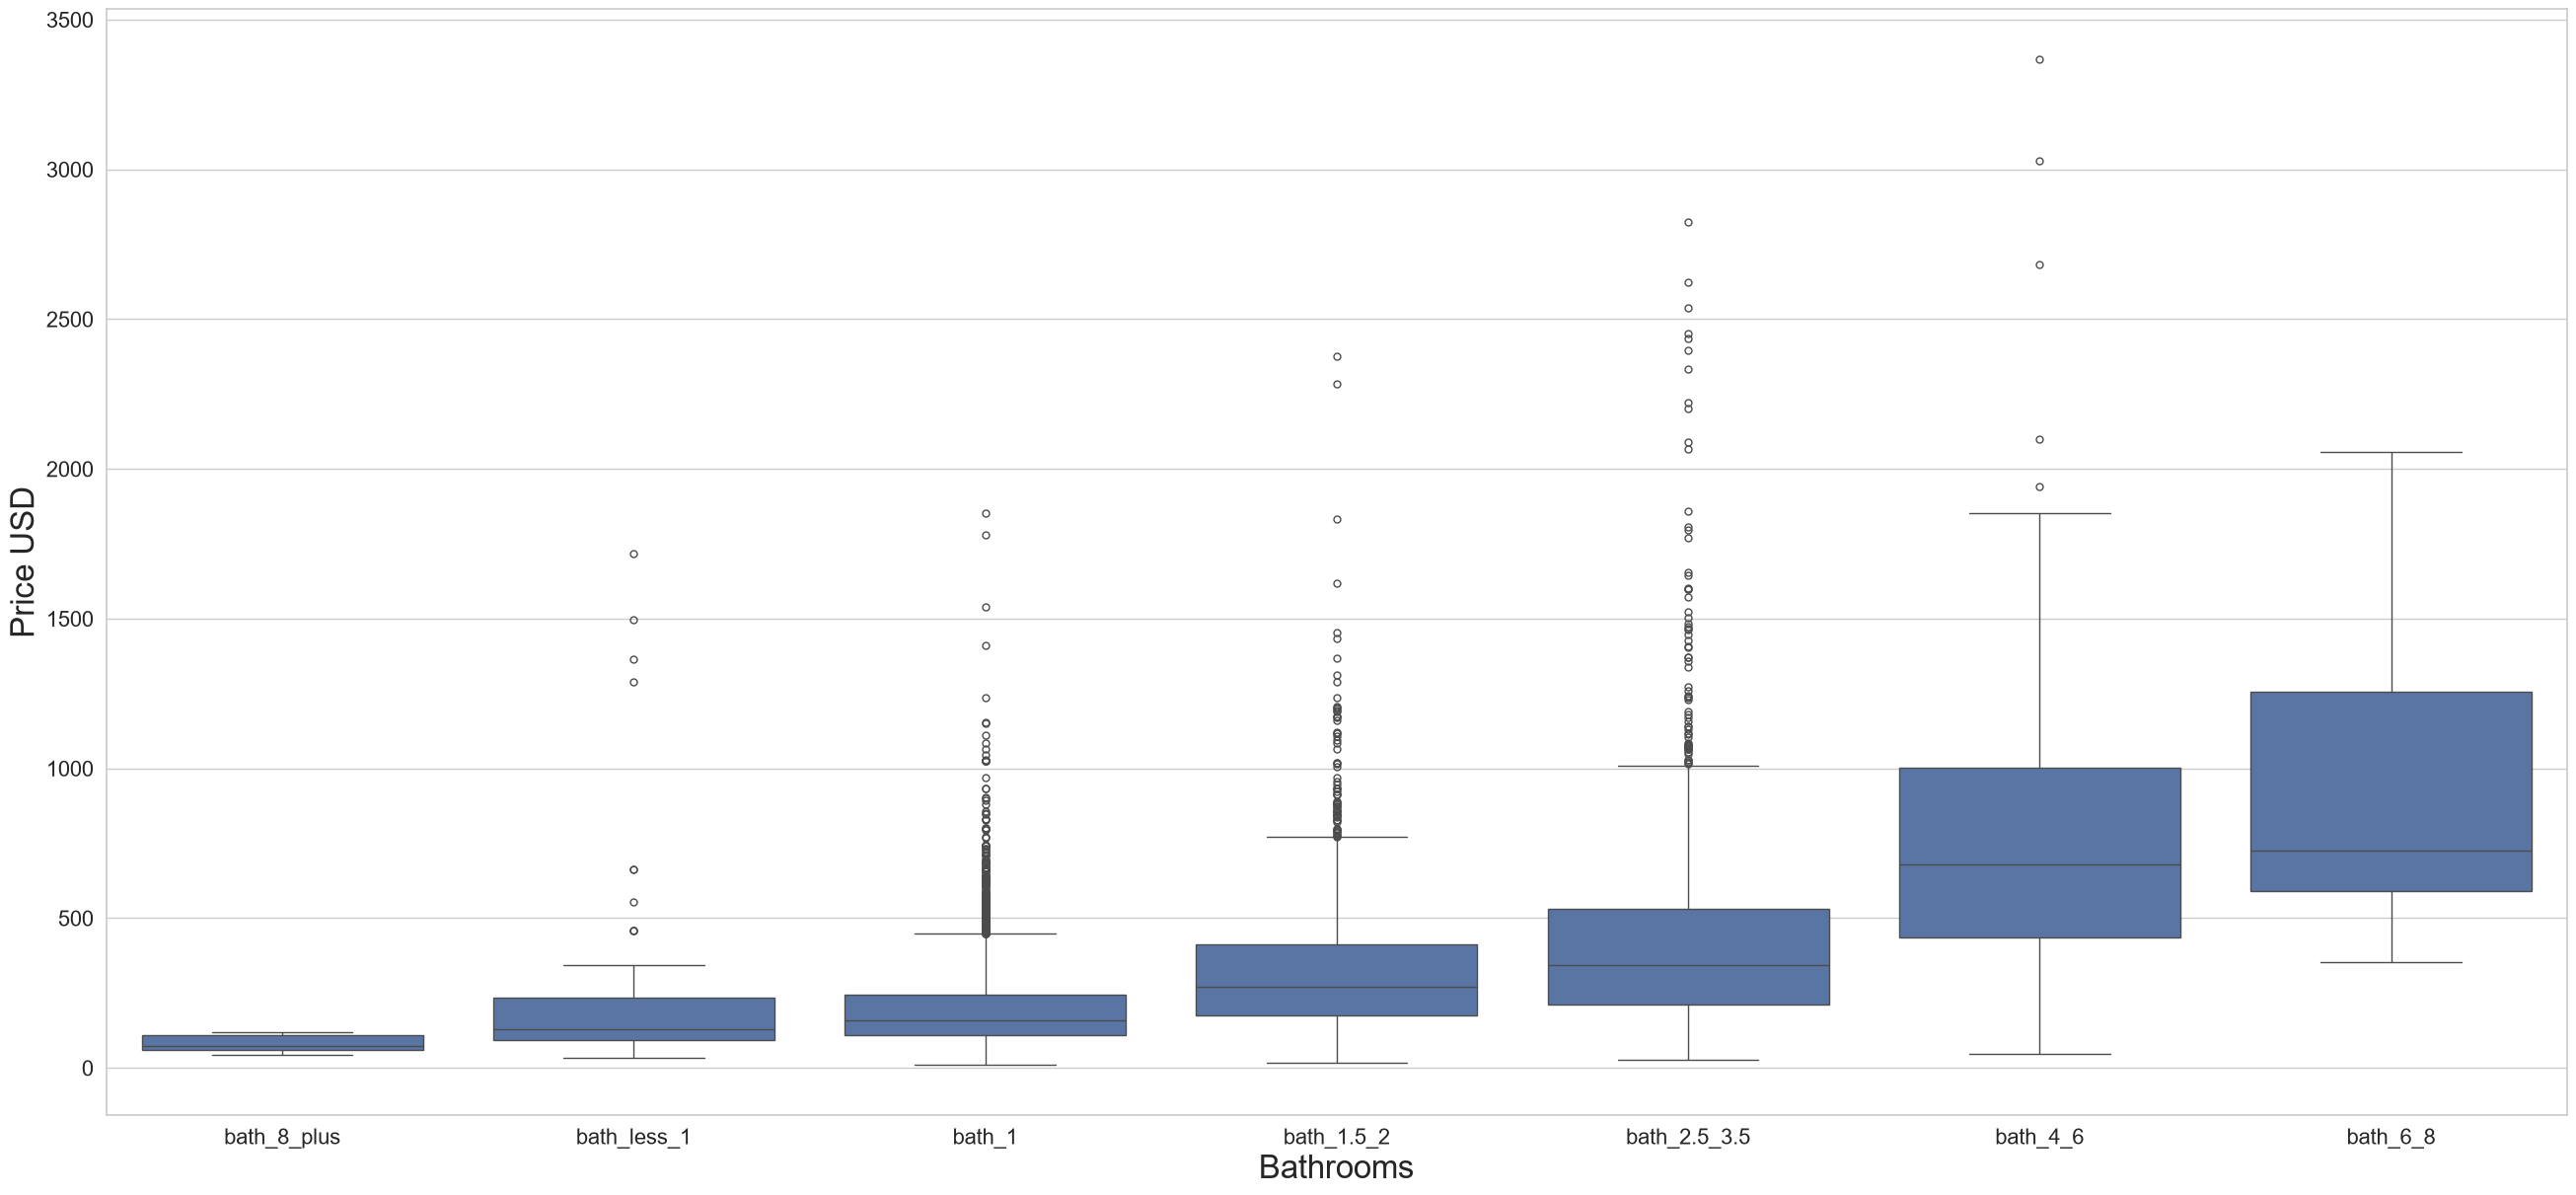

In [41]:
order = train_set.groupby(by=["bathrooms_cat"])["price"].median().sort_values().index
viz.plot_boxplot_one_fig(train_set,col='price',bins='bathrooms_cat',x_axis_order=order,y_label='Price USD',x_label='Bathrooms')
plt.show();

In [42]:
train_set = dpr.condense_prop_type(train_set)

In [43]:
train_set = dpr.drop_cols(train_set,col_after_ftr_drop)

### Some Key Takeaways from EDA
* Right-skewed distribution for target and a few features. Target will be log-transformed for OLS models. 
* Median price varies heavily depending on location, room type, and other categorical features. 
* Observed non-linear relationships between some features (such as minimum nights) and price, demonstrating that 
treating them as categorical tiers may capture pricing nuances much better than a continuous linear assumption.

In [44]:
train_set_clean = train_set.copy()

In [45]:
train_set_clean.info()

<class 'pandas.DataFrame'>
Index: 10472 entries, 0 to 14764
Data columns (total 28 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            10472 non-null  int64  
 1   host_is_superhost                             10472 non-null  str    
 2   neighbourhood_cleansed                        10472 non-null  str    
 3   neighbourhood_group_cleansed                  10472 non-null  str    
 4   room_type                                     10472 non-null  str    
 5   accommodates                                  10472 non-null  int64  
 6   bathrooms                                     10472 non-null  float64
 7   bedrooms                                      10472 non-null  float64
 8   beds                                          10472 non-null  float64
 9   price                                         10472 non-null  float64
 10  mi

## Model Prototyping

### Statsmodels OLS scaling and analysis 

In [46]:
model_1_num_features = config['models']['sm_ols_model_1']['features']['numeric']
model_1_cat_features = config['models']['sm_ols_model_1']['features']['categorical']
model_1_features = model_1_num_features + model_1_cat_features

y_train_m1, X_train_m1 = dpr.prep_data_ols_statsmodels(train_set_clean,features=model_1_features,
                                                       cat_features=model_1_cat_features,
                                                              target='price',log_transform=True)

In [47]:
model_1 = sm.OLS(y_train_m1,X_train_m1)
m1_results = model_1.fit()

In [48]:
print(m1_results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.696
Model:                            OLS   Adj. R-squared:                  0.695
Method:                 Least Squares   F-statistic:                     597.6
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:41:53   Log-Likelihood:                -5034.0
No. Observations:               10472   AIC:                         1.015e+04
Df Residuals:                   10431   BIC:                         1.045e+04
Df Model:                          40                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [49]:
ev.show_vif(X_train_m1)

,feature,vif
0,const,1.000000
1,accommodates,6.140095
2,minimum_nights,1.242720
3,bathrooms,4.678834
4,review_scores_rating,1.161051
5,bedrooms,5.086881
6,calculated_host_listings_count_private_rooms,1.502408
7,bath_per_accom,3.362594
8,calculated_host_listings_count,1.354954
9,room_type_Hotel room,1.075698


In [50]:
predicts_orig_scale,target_orig_scale = dpr.log_re_transformation(m1_results)

In [51]:
model_1_eval = ev.eval_model_sm(m1_results,predicted_vals=predicts_orig_scale,
                                target=target_orig_scale,name="OLS Model 1")
print(model_1_eval)

    model_name        mae        rmse      mape  r2_score
0  OLS Model 1  82.278914  151.913726  0.347661  0.695028


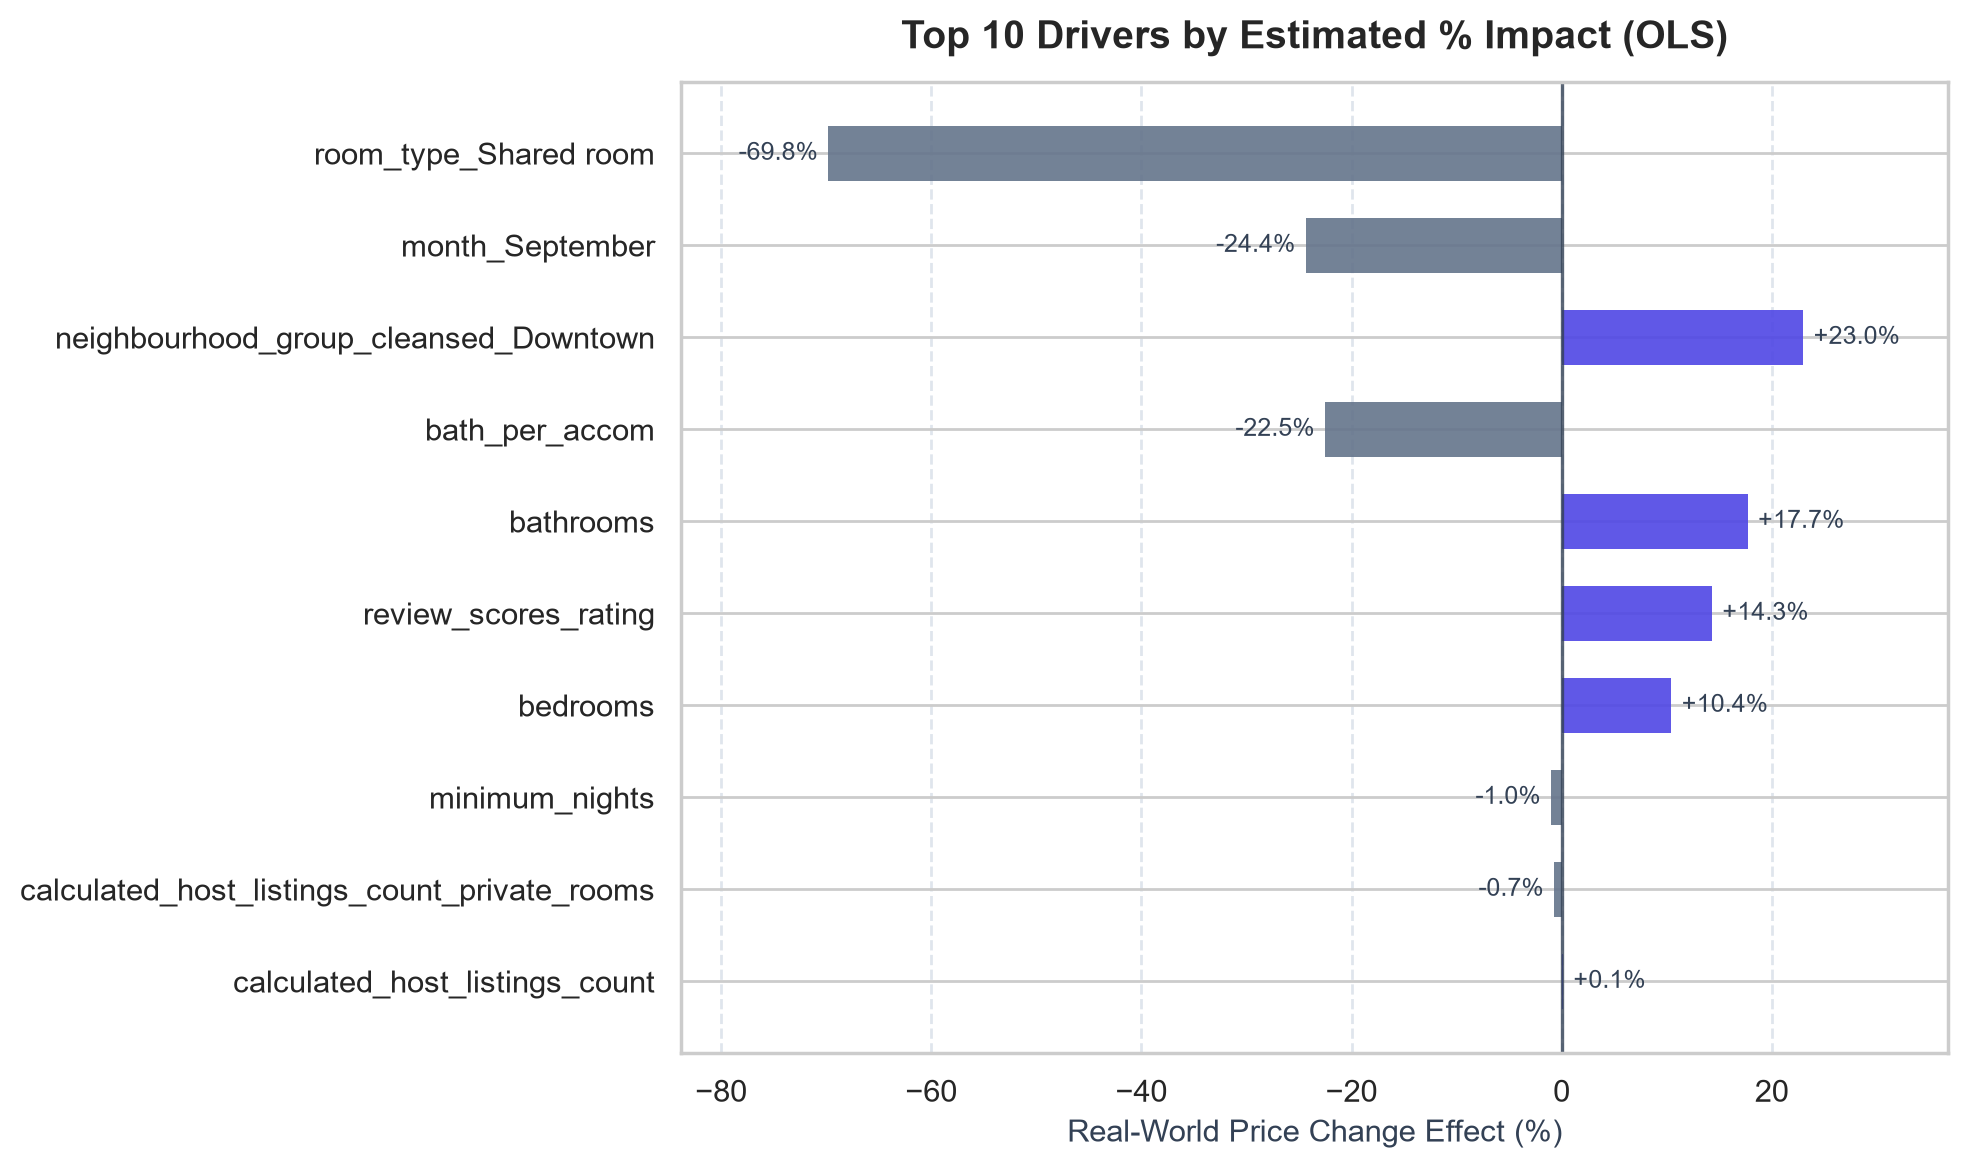

In [52]:
m1_feat_imp = ev.sm_feature_imp(m1_results)
viz.feat_imp_bar_chart_ols(m1_feat_imp);

In [53]:
cv_scores_m1 = ev.cross_validate_five_split(features_encoded=X_train_m1,raw_target=train_set_clean['price'],
                                            split_group=train_set_clean['id'],log_transform=True)
cv_scores_m1

,model_name,cv_avg_mae,cv_mae_std_dev,cv_avg_rmse,cv_rmse_std_dev
0,model,79.215761,2.201797,154.217082,8.261688


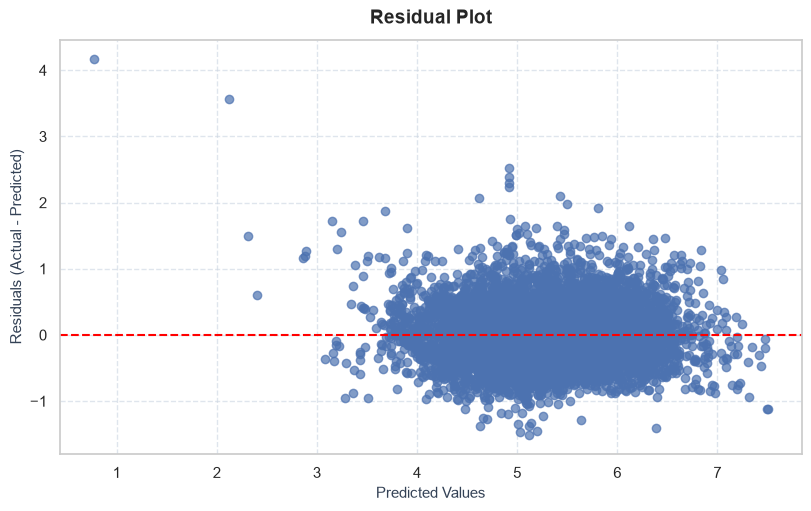

In [54]:
viz.plot_resids_predicted(m1_results);

In [55]:
model_1_bin_eval = ev.eval_binned_targets(target=target_orig_scale,predicted_vals=predicts_orig_scale)
print(model_1_bin_eval)

  model_name   bin_type price_group         mae        rmse      mape
0      model  predicted       <$100   25.559791   36.138565  0.372521
1      model  predicted   $100-$250   53.341958   85.833738  0.361974
2      model  predicted   $250-$500  101.787746  158.159307  0.312045
3      model  predicted  $500-$1000  221.339130  332.530640  0.364702
4      model  predicted      $1000+  527.195384  689.528660  0.601592


In [56]:
model_1_raw_bin_eval = ev.eval_bin_target_raw_err(target=target_orig_scale,predicted_vals=predicts_orig_scale)
print(model_1_raw_bin_eval)

  model_name   bin_type price_group        mean      median  count
0      model  predicted       <$100   -2.028329    3.921837    916
1      model  predicted   $100-$250    6.815715   21.056496   5197
2      model  predicted   $250-$500   -5.613112   27.114108   3539
3      model  predicted  $500-$1000  -20.844823   65.834701    757
4      model  predicted      $1000+  192.759259  339.116023     63


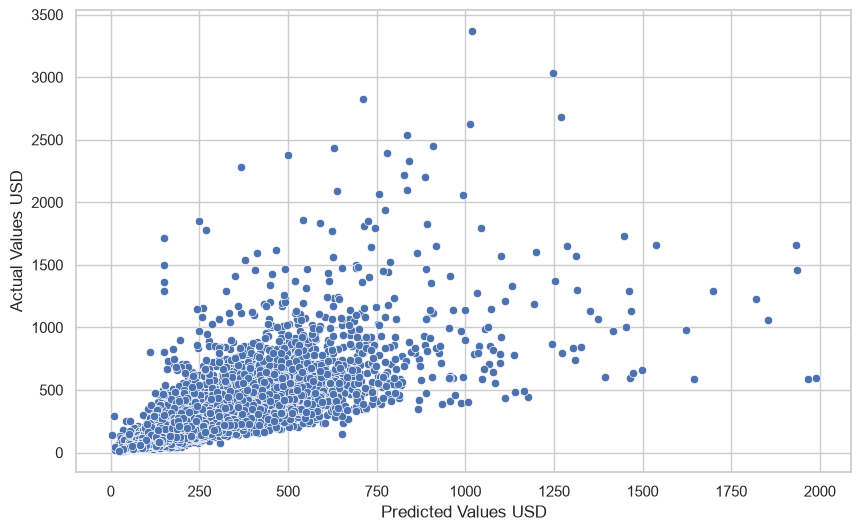

In [57]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=predicts_orig_scale,y=target_orig_scale)
plt.xlabel('Predicted Values USD')
plt.ylabel('Actual Values USD')
plt.show();

In [58]:
model_1_bin_eval_actual = ev.eval_binned_targets(target=target_orig_scale,predicted_vals=predicts_orig_scale,
                                                 bin_group='actual',name='model_1_ols')
print(model_1_bin_eval_actual)

    model_name bin_type price_group         mae        rmse      mape
0  model_1_ols   actual       <$100   41.659719   52.548863  0.609857
1  model_1_ols   actual   $100-$250   52.056078   68.712637  0.323406
2  model_1_ols   actual   $250-$500   84.854487  114.201911  0.242234
3  model_1_ols   actual  $500-$1000  208.679297  263.396023  0.311469
4  model_1_ols   actual      $1000+  738.249802  865.345017  0.498417


In [59]:
model_1_raw_bin_eval_actual = ev.eval_bin_target_raw_err(target=target_orig_scale,predicted_vals=predicts_orig_scale,
                                                         bin_group='actual',name='model_1_ols')
print(model_1_raw_bin_eval_actual)

    model_name bin_type price_group        mean      median  count
0  model_1_ols   actual       <$100   38.751203   35.085868   1643
1  model_1_ols   actual   $100-$250   34.745766   30.004217   4951
2  model_1_ols   actual   $250-$500   -1.661818  -10.114542   2887
3  model_1_ols   actual  $500-$1000 -134.953884 -154.527822    833
4  model_1_ols   actual      $1000+ -686.186337 -654.453722    158


*Residual plot for some features also shows evidence of heterodascity*

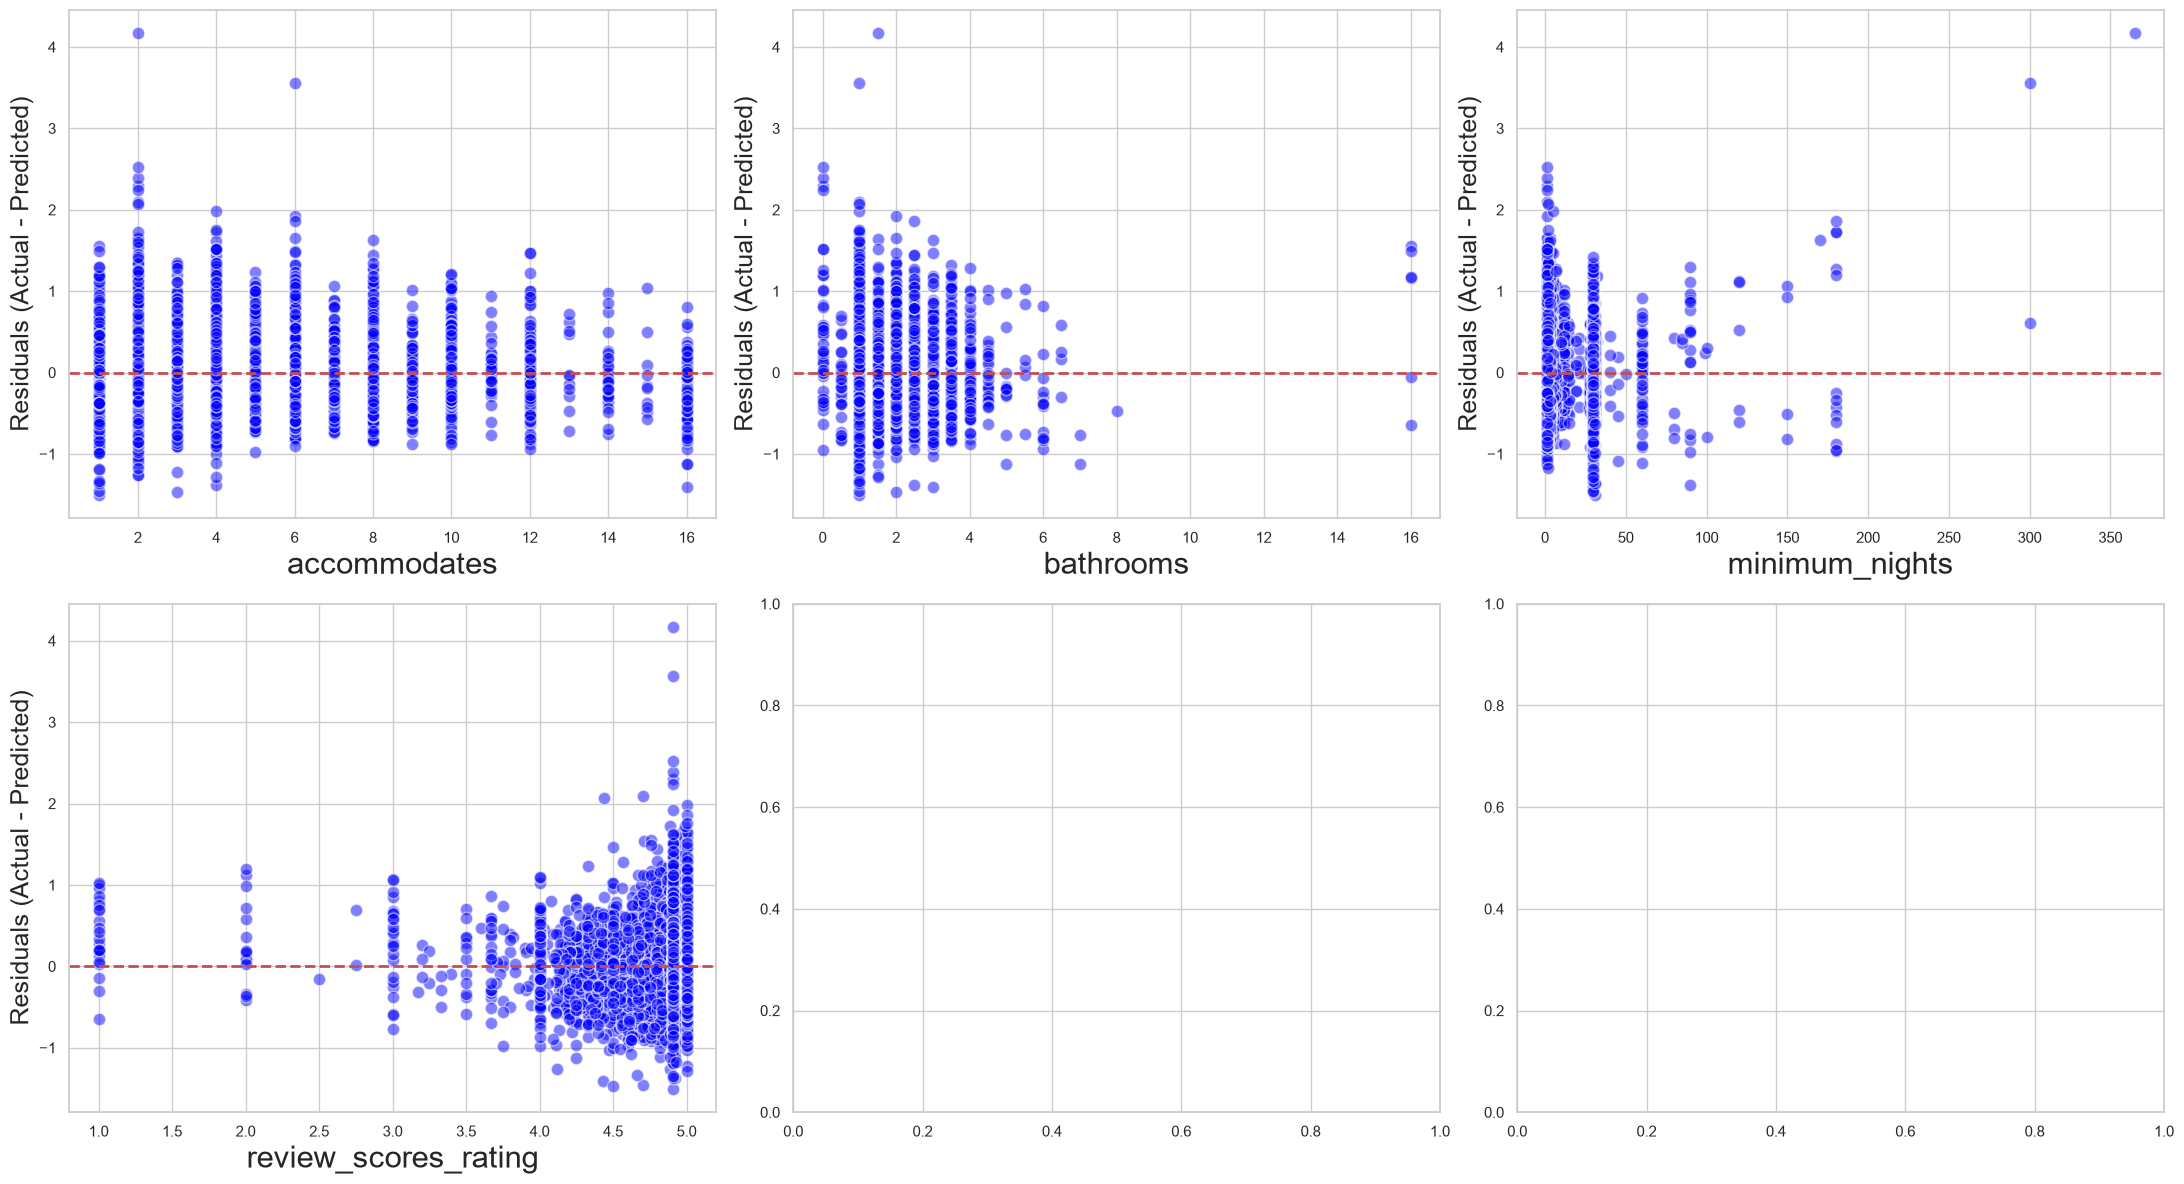

In [60]:
features_resid = ['accommodates','bathrooms','minimum_nights','review_scores_rating']
viz.plot_resids_features(m1_results,features_resid);

### OLS model with binned features

In [61]:
model_2_num_features = config['models']['sm_ols_model_2']['features']['numeric']
model_2_cat_features = config['models']['sm_ols_model_2']['features']['categorical']
model_2_features = model_2_num_features + model_2_cat_features

y_train_m2,X_train_m2 = dpr.prep_data_ols_statsmodels(train_set_clean,target='price',features=model_2_features,
                                                      cat_features=model_2_cat_features,log_transform=True)

In [62]:
model_2 = sm.OLS(y_train_m2,X_train_m2)
model_2_results = model_2.fit()

In [63]:
print(model_2_results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.706
Method:                 Least Squares   F-statistic:                     433.9
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:42:00   Log-Likelihood:                -4838.9
No. Observations:               10472   AIC:                             9796.
Df Residuals:                   10413   BIC:                         1.022e+04
Df Model:                          58                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [64]:
predicts_orig_scale_m2,target_orig_scale_m2 = dpr.log_re_transformation(model_2_results)

In [65]:
model_2_eval = ev.eval_model_sm(model_2_results,predicted_vals=predicts_orig_scale_m2,target=target_orig_scale_m2,
                                name='OLS Model 2')
model_2_eval

,model_name,mae,rmse,mape,r2_score
0,OLS Model 2,80.659757,149.649245,0.339929,0.705677


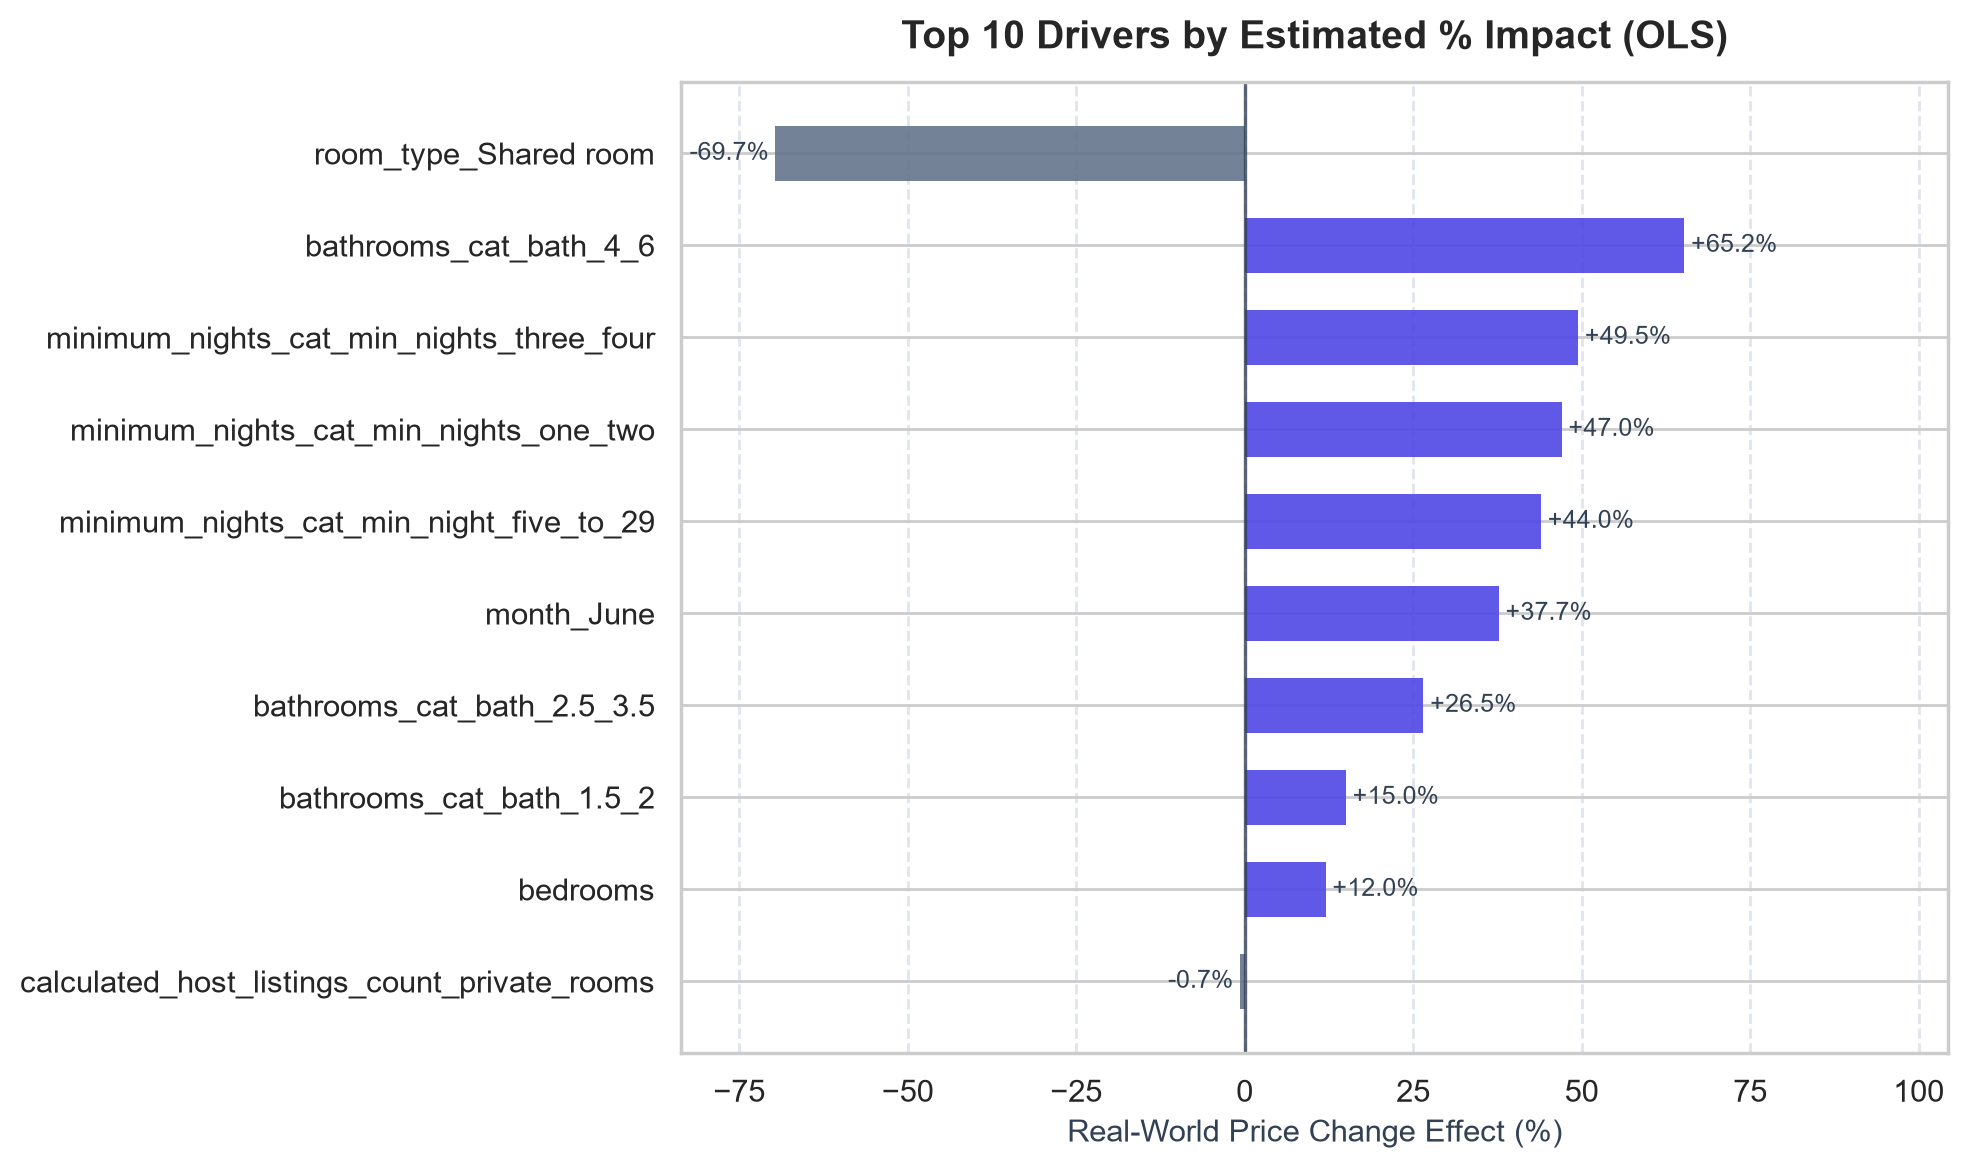

In [66]:
m2_feat_imp = ev.sm_feature_imp(model_2_results)
viz.feat_imp_bar_chart_ols(m2_feat_imp);

In [67]:
cv_scores_m2 = ev.cross_validate_five_split(features_encoded=X_train_m2,raw_target=train_set_clean['price'],
                                            split_group=train_set_clean['id'])
cv_scores_m2

,model_name,cv_avg_mae,cv_mae_std_dev,cv_avg_rmse,cv_rmse_std_dev
0,model,78.407085,2.322607,153.287299,9.828403


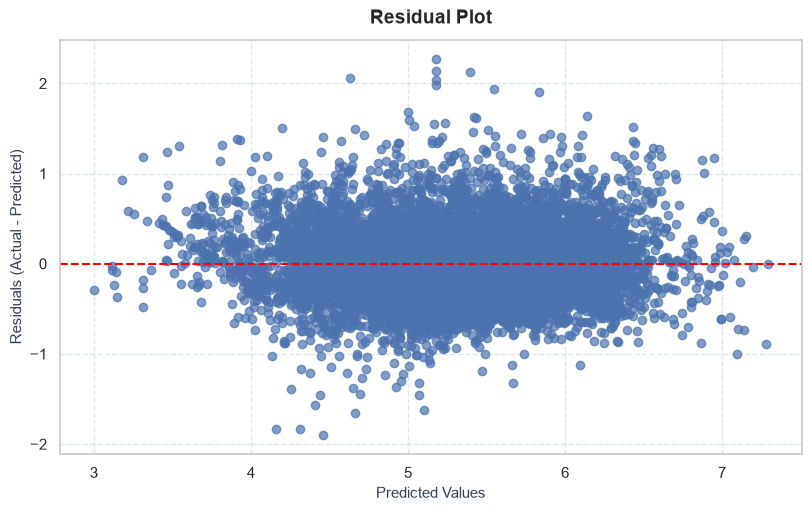

In [68]:
viz.plot_resids_predicted(model_2_results);

In [69]:
model_2_bin_eval = ev.eval_binned_targets(target=target_orig_scale_m2,predicted_vals=predicts_orig_scale_m2,
                                          name='model_2_ols')
print(model_2_bin_eval)

    model_name   bin_type price_group         mae        rmse      mape
0  model_2_ols  predicted       <$100   25.719778   35.823845  0.361327
1  model_2_ols  predicted   $100-$250   53.306363   88.243711  0.353768
2  model_2_ols  predicted   $250-$500  100.424466  152.385344  0.312271
3  model_2_ols  predicted  $500-$1000  220.248303  343.683093  0.339466
4  model_2_ols  predicted      $1000+  468.691351  671.360668  0.480211


In [70]:
model_2_bin_eval_raw = ev.eval_bin_target_raw_err(target=target_orig_scale_m2,predicted_vals=predicts_orig_scale_m2,
                                                  name='model_2_ols')
print(model_2_bin_eval_raw)

    model_name   bin_type price_group       mean      median  count
0  model_2_ols  predicted       <$100  -5.425324   -0.483265   1038
1  model_2_ols  predicted   $100-$250   5.193759   20.331512   5069
2  model_2_ols  predicted   $250-$500  -2.288096   29.988659   3539
3  model_2_ols  predicted  $500-$1000 -43.128049   49.410124    784
4  model_2_ols  predicted      $1000+  11.028297  142.856247     42


In [71]:
m2_predicts_targets = pd.concat([predicts_orig_scale_m2,target_orig_scale_m2],axis=1,keys=("pred_price","actual_price"))
m2_predicts_targets['dif'] = m2_predicts_targets['pred_price'] - m2_predicts_targets['actual_price']
m2_predicts_targets['dif_abs'] = np.abs(m2_predicts_targets['pred_price'] - m2_predicts_targets['actual_price'])
m2_predicts_targets[m2_predicts_targets['dif_abs'] > 2000]

,pred_price,actual_price,dif,dif_abs
3942,1126.198610,3367.0,-2240.801390,2240.801390
6830,673.857482,2823.4,-2149.542518,2149.542518


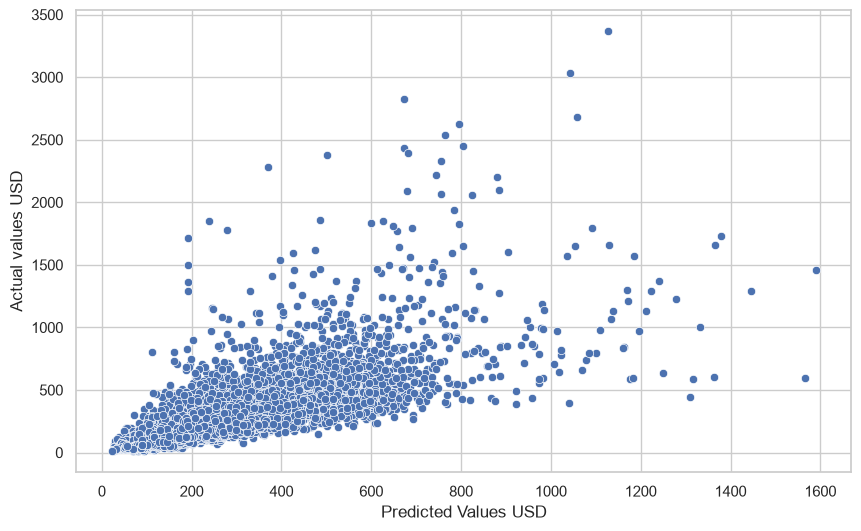

In [72]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=predicts_orig_scale_m2,y=target_orig_scale_m2)
plt.ylabel('Actual values USD')
plt.xlabel('Predicted Values USD')
plt.show();

In [73]:
model_2_bin_eval_actual = ev.eval_binned_targets(target=target_orig_scale_m2,predicted_vals=predicts_orig_scale_m2,
                                                 bin_group='actual',name='model_2_ols')
print(model_2_bin_eval_actual)

    model_name bin_type price_group         mae        rmse      mape
0  model_2_ols   actual       <$100   39.032534   49.757485  0.581337
1  model_2_ols   actual   $100-$250   51.917460   67.839489  0.321414
2  model_2_ols   actual   $250-$500   83.573514  110.183478  0.239399
3  model_2_ols   actual  $500-$1000  195.745316  243.318950  0.290711
4  model_2_ols   actual      $1000+  754.193588  883.390242  0.506161


In [74]:
model_2_bin_eval_raw_actual = ev.eval_bin_target_raw_err(target=target_orig_scale_m2,predicted_vals=predicts_orig_scale_m2,
                                                         bin_group='actual',name='model_2_ols')
print(model_2_bin_eval_raw_actual)

    model_name bin_type price_group        mean      median  count
0  model_2_ols   actual       <$100   34.906624   30.380344   1643
1  model_2_ols   actual   $100-$250   33.365468   29.906035   4951
2  model_2_ols   actual   $250-$500   -1.516454   -7.539590   2887
3  model_2_ols   actual  $500-$1000 -145.727753 -150.817262    833
4  model_2_ols   actual      $1000+ -743.834736 -686.204068    158


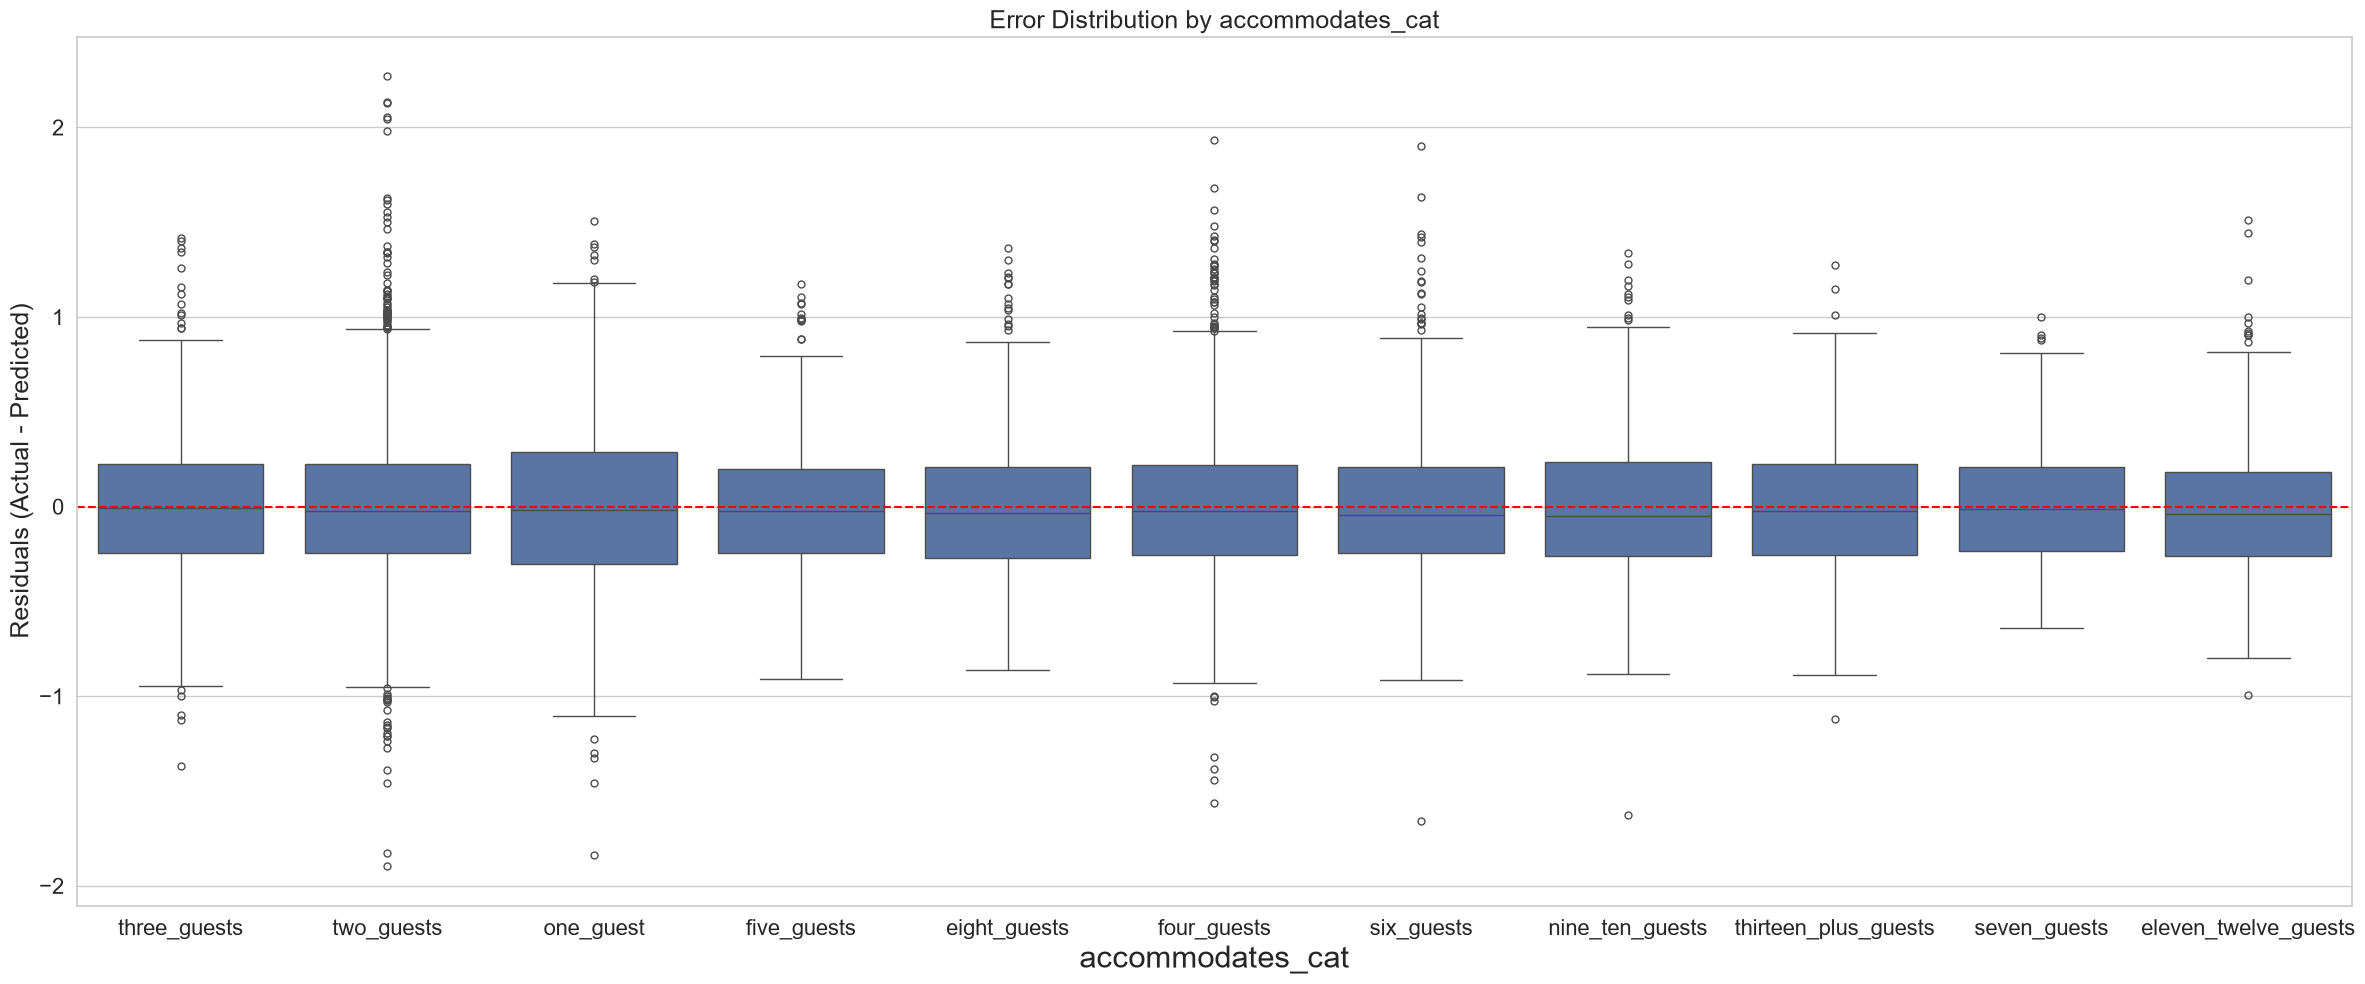

In [75]:
viz.plot_resid_boxplt(model_2_results,train_set_clean,'accommodates_cat');

### First HGBR model

In [76]:
y_train_m3 = train_set_clean['price']
numeric_cols = config['models']['hist_model_3']['features']['numeric']
cat_cols = config['models']['hist_model_3']['features']['categorical']
X_train_m3 = train_set_clean[numeric_cols]
X_train_m3[cat_cols] = train_set_clean[cat_cols].astype('category')

In [77]:
hyperparams_m3 = config['models']['hist_model_3']['hyperparameters']
model_3 = HistGradientBoostingRegressor(**hyperparams_m3)
model_3 = model_3.fit(X_train_m3,y_train_m3.squeeze())

In [78]:
fitted_val_m3 = model_3.predict(X_train_m3)

In [79]:
m3_eval = ev.eval_tree_model(target=y_train_m3,predicted_vals=fitted_val_m3,name='Model 3')
m3_eval

,model_name,mae,rmse,mape,r2_score
0,Model 3,66.268173,118.557519,0.279335,0.724508


In [80]:
m3_cv = ev.cross_val_5_split_sklearn(model=model_3,X=X_train_m3,y=y_train_m3,name='Model 3 CV',
                                     group=train_set_clean['id'])
m3_cv

,model_name,cv_avg_mae,cv_mae_std_dev,cv_avg_rmse,cv_rmse_std_dev
0,Model 3 CV,74.039977,2.228805,136.29894,8.515767


In [81]:
perm_hyperparams = config['evals']['permutation_settings']
perm_importance = ev.hgbr_feat_imp(model_3,X_train_m3,y_train_m3,perm_hyperparams)
perm_importance

,feature_names,mean_r2_decrease,std_r2_decrease
17,month,0.338094,0.012231
0,accommodates,0.145360,0.003719
1,minimum_nights,0.137563,0.007707
4,bedrooms,0.116049,0.003802
2,bathrooms,0.102978,0.002193
9,neighbourhood_group_cleansed,0.081848,0.002133
3,review_scores_rating,0.042269,0.003561
7,calculated_host_listings_count,0.039702,0.002367
16,host_is_superhost,0.024181,0.003997
5,calculated_host_listings_count_private_rooms,0.017231,0.001341


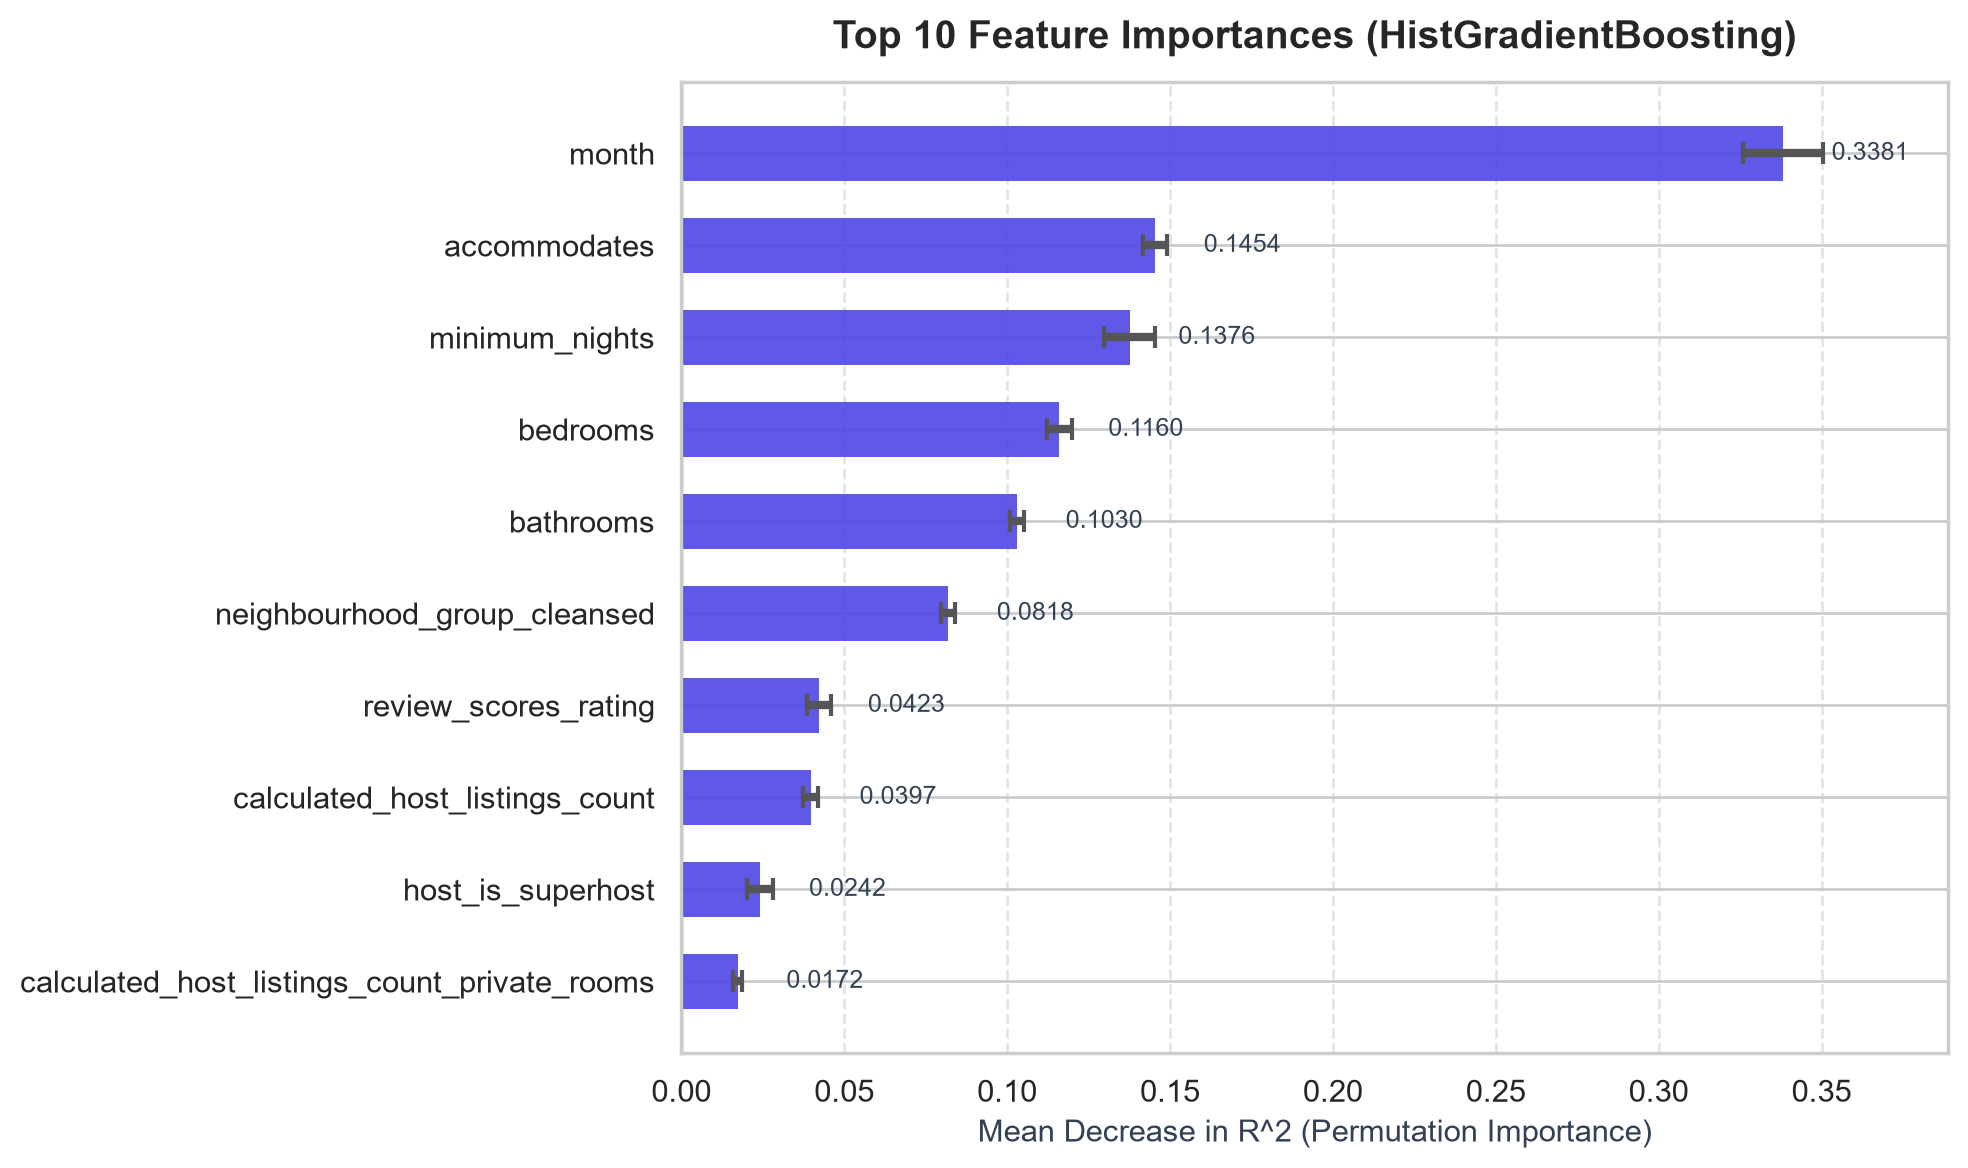

In [82]:
viz.feat_imp_bar_chart_hgbr(perm_importance);

In [83]:
metrics = ["neg_mean_absolute_error","neg_median_absolute_error","neg_mean_absolute_percentage_error",
           "neg_root_mean_squared_error"]
gkf = GroupKFold(n_splits=5)

cv_results = cross_validate(model_3, X_train_m3, y_train_m3, groups=train_set_clean["id"], cv=gkf, scoring=metrics)
print("Average Median Error:", -cv_results["test_neg_median_absolute_error"].mean())
print("Average MAPE:", -cv_results["test_neg_mean_absolute_percentage_error"].mean())

Average Median Error: 41.17942116447445
Average MAPE: 0.30403644981610756


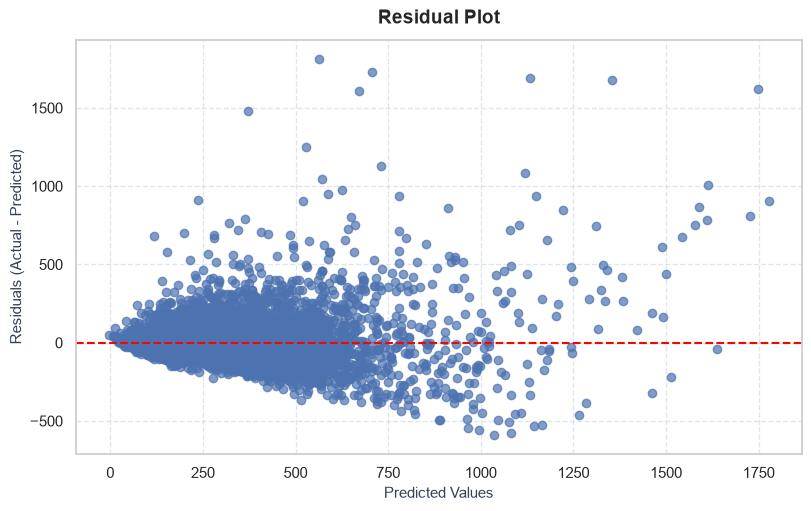

In [84]:
residuals_m3 = y_train_m3 - fitted_val_m3
viz.plot_resids_sklearn(pred_vals=fitted_val_m3,resids=residuals_m3);

In [85]:
results_m3_bins = ev.eval_binned_targets(target=y_train_m3,predicted_vals=fitted_val_m3,name='model_3_hgbr')
results_m3_bins

,model_name,bin_type,price_group,mae,rmse,mape
0,model_3_hgbr,predicted,<$100,19.684867,28.428298,0.321251
1,model_3_hgbr,predicted,$100-$250,39.780290,59.333035,0.271483
2,model_3_hgbr,predicted,$250-$500,85.244186,120.315908,0.270348
3,model_3_hgbr,predicted,$500-$1000,177.926822,253.684364,0.305662
4,model_3_hgbr,predicted,$1000+,412.175273,544.420454,0.303708


In [86]:
results_m3_bins_raw = ev.eval_bin_target_raw_err(target=y_train_m3,predicted_vals=fitted_val_m3,name='model_3_hgbr')
results_m3_bins_raw

,model_name,bin_type,price_group,mean,median,count
0,model_3_hgbr,predicted,<$100,1.274198,3.697759,1052
1,model_3_hgbr,predicted,$100-$250,1.653789,10.161209,5247
2,model_3_hgbr,predicted,$250-$500,3.487423,21.653704,3210
3,model_3_hgbr,predicted,$500-$1000,0.561270,47.010288,878
4,model_3_hgbr,predicted,$1000+,-206.919855,-167.128270,84


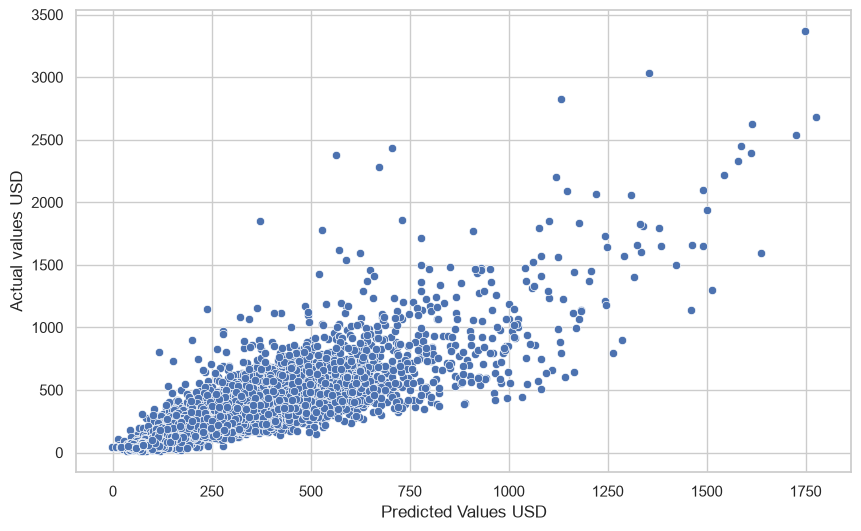

In [87]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_val_m3,y=y_train_m3)
plt.ylabel('Actual values USD')
plt.xlabel('Predicted Values USD')
plt.show();

In [88]:
results_m3_bins_actual = ev.eval_binned_targets(target=y_train_m3,predicted_vals=fitted_val_m3,bin_group='actual',
                                                name='model_3_hgbr')
results_m3_bins_actual

,model_name,bin_type,price_group,mae,rmse,mape
0,model_3_hgbr,actual,<$100,29.295019,38.959687,0.474387
1,model_3_hgbr,actual,$100-$250,41.028760,57.604595,0.247851
2,model_3_hgbr,actual,$250-$500,78.686973,104.653459,0.226052
3,model_3_hgbr,actual,$500-$1000,162.640111,206.120493,0.243834
4,model_3_hgbr,actual,$1000+,509.372473,623.014210,0.345311


In [89]:
results_m3_bins_raw_actual = ev.eval_bin_target_raw_err(target=y_train_m3,predicted_vals=fitted_val_m3,bin_group='actual',
                                                        name='model_3_hgbr')
results_m3_bins_raw_actual

,model_name,bin_type,price_group,mean,median,count
0,model_3_hgbr,actual,<$100,25.534009,22.193033,1680
1,model_3_hgbr,actual,$100-$250,22.068220,15.742022,4914
2,model_3_hgbr,actual,$250-$500,4.202243,-4.293930,2887
3,model_3_hgbr,actual,$500-$1000,-96.765317,-103.495794,833
4,model_3_hgbr,actual,$1000+,-497.411612,-438.800901,158


### HGBR model with gamma loss function


In [90]:
y_train_m4 = train_set_clean['price']
numeric_cols = config['models']['hist_model_4']['features']['numeric']
cat_cols = config['models']['hist_model_4']['features']['categorical']

X_train_m4 = train_set_clean[numeric_cols]
X_train_m4[cat_cols] = train_set_clean[cat_cols].astype('category')

In [91]:
hyperparams_m4 = config['models']['hist_model_4']['hyperparameters']

In [92]:
model_4 = HistGradientBoostingRegressor(**hyperparams_m4)
model_4 = model_4.fit(X_train_m4,y_train_m4)

In [93]:
fitted_val_m4 = model_4.predict(X_train_m4)

In [94]:
m4_eval = ev.eval_tree_model(target=y_train_m4,predicted_vals=fitted_val_m4,name='Model 4')
m4_eval

,model_name,mae,rmse,mape,r2_score
0,Model 4,61.752292,116.472794,0.23587,0.734111


In [95]:
m4_cv = ev.cross_val_5_split_sklearn(model=model_4,X=X_train_m4,y=y_train_m4,name='Model 4 CV',
                                     group=train_set_clean['id'])
m4_cv

,model_name,cv_avg_mae,cv_mae_std_dev,cv_avg_rmse,cv_rmse_std_dev
0,Model 4 CV,70.968294,2.030165,134.821263,9.075145


In [96]:
perm_hyperparams = config['evals']['permutation_settings']
m4_feat_imp = ev.hgbr_feat_imp(model_4,X_train_m4,y_train_m4,perm_hyperparams)

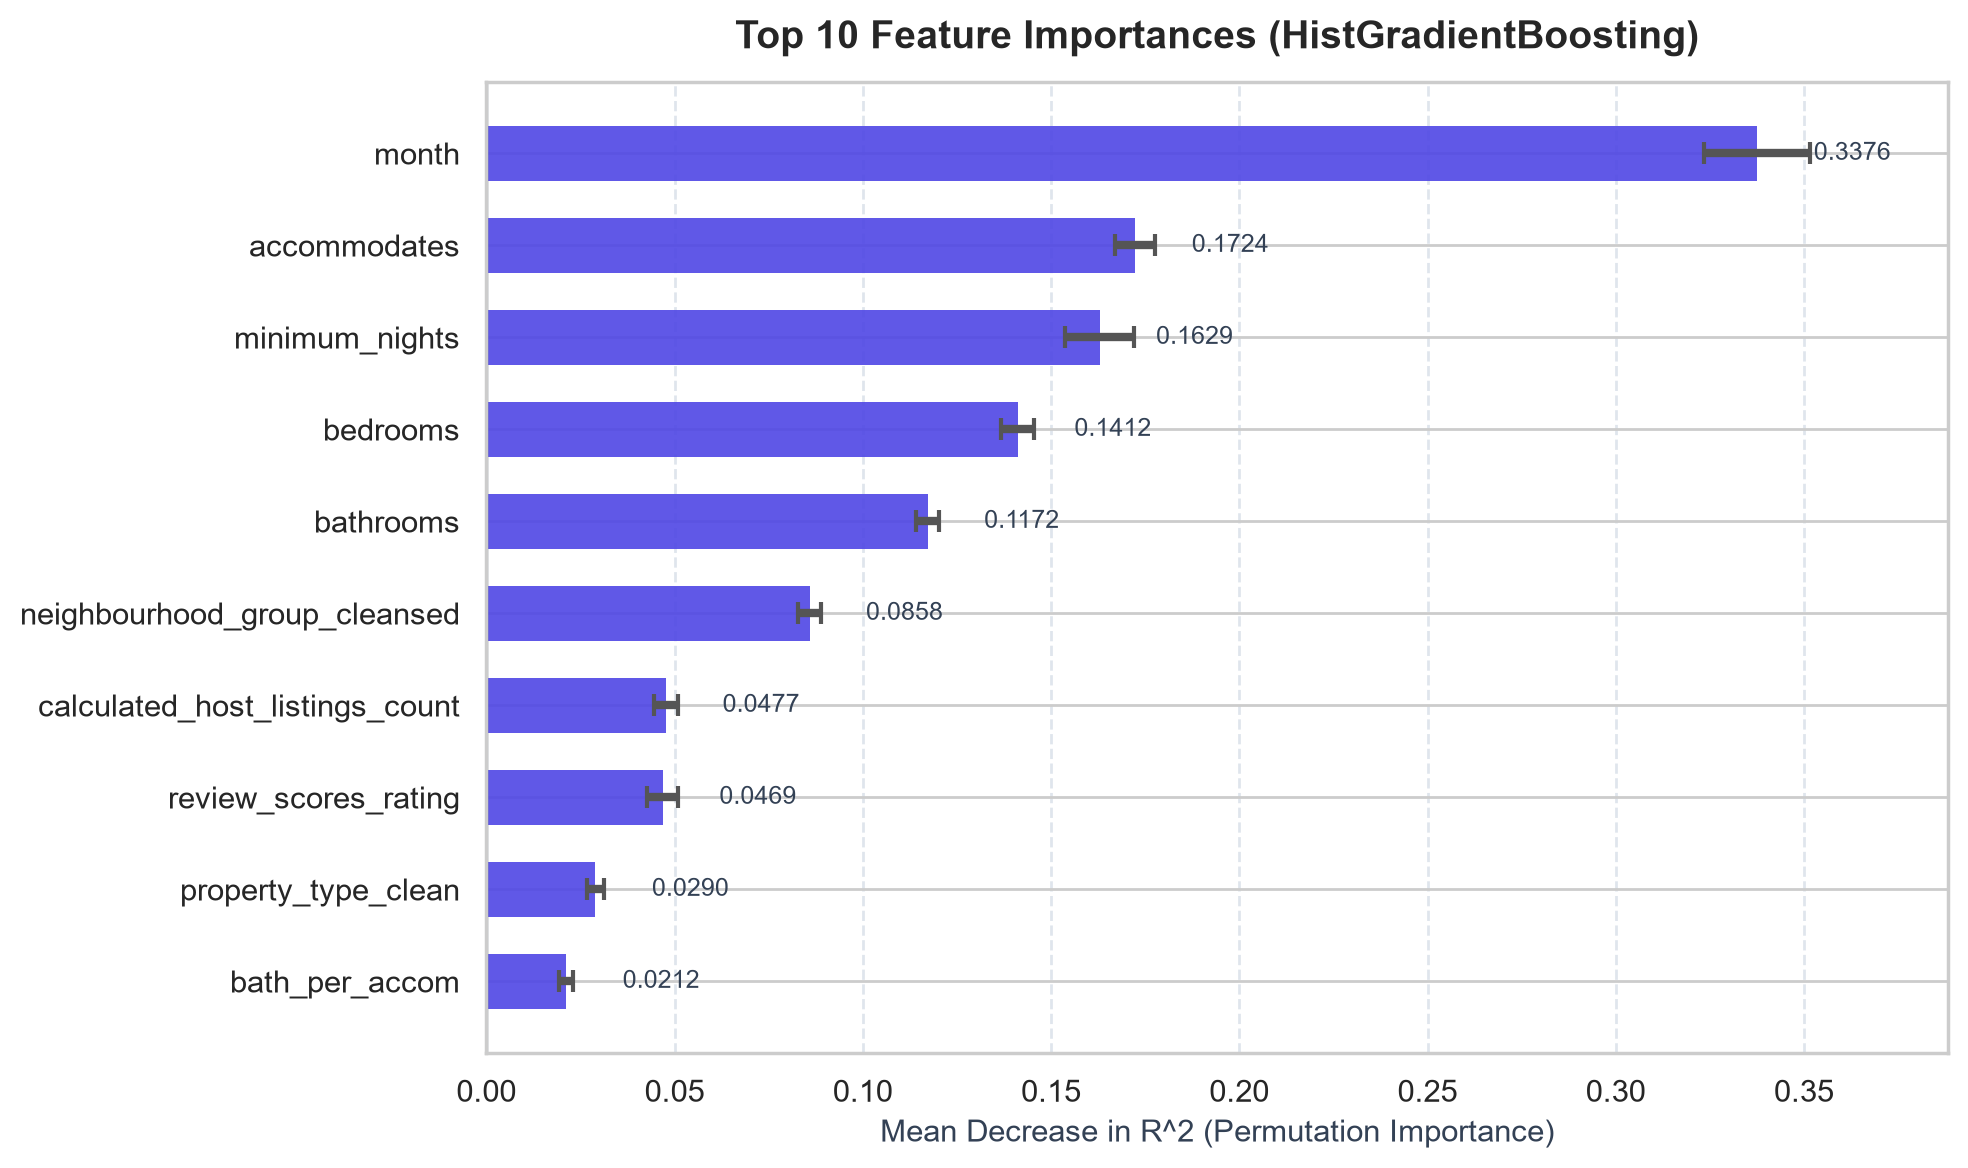

In [97]:
viz.feat_imp_bar_chart_hgbr(m4_feat_imp);

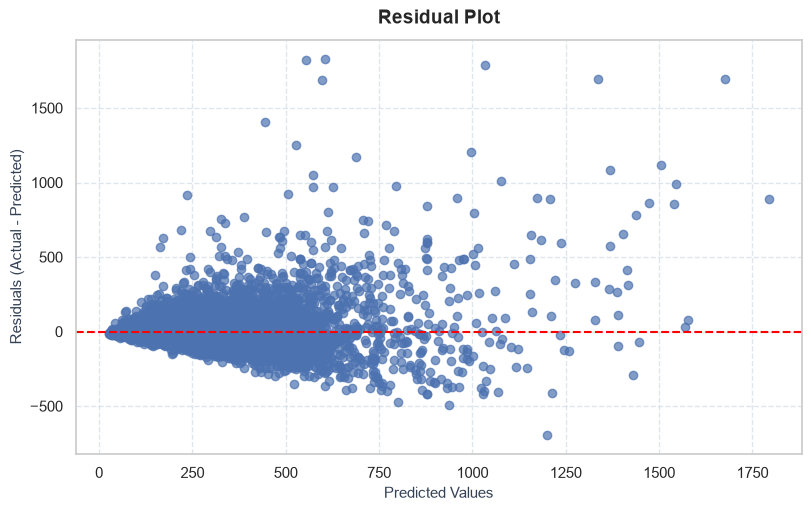

In [98]:
residuals_m4 = y_train_m4 - fitted_val_m4
viz.plot_resids_sklearn(pred_vals=fitted_val_m4,resids=residuals_m4);

In [99]:
results_m4_bins = ev.eval_binned_targets(target=y_train_m4,predicted_vals=fitted_val_m4)
results_m4_bins

,model_name,bin_type,price_group,mae,rmse,mape
0,model,predicted,<$100,13.742523,20.260986,0.210836
1,model,predicted,$100-$250,35.331920,53.762281,0.223711
2,model,predicted,$250-$500,80.990278,114.714517,0.249659
3,model,predicted,$500-$1000,180.560255,262.788985,0.285912
4,model,predicted,$1000+,442.165428,599.865098,0.282122


In [100]:
results_m4_bins_raw = ev.eval_bin_target_raw_err(target=y_train_m4,predicted_vals=fitted_val_m4)
results_m4_bins_raw

,model_name,bin_type,price_group,mean,median,count
0,model,predicted,<$100,0.827826,2.260618,1166
1,model,predicted,$100-$250,0.483381,7.248010,5104
2,model,predicted,$250-$500,-0.332370,17.798705,3276
3,model,predicted,$500-$1000,-27.073744,24.818702,858
4,model,predicted,$1000+,-285.340664,-190.921752,68


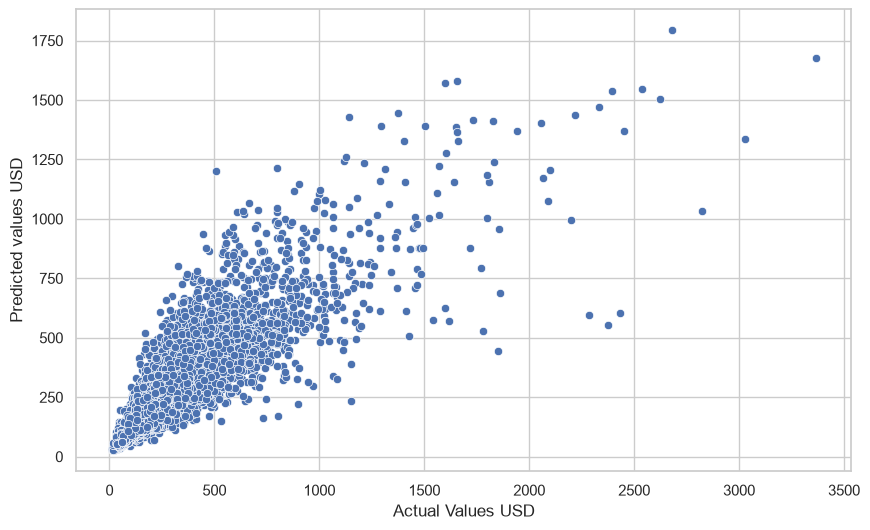

In [101]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_train_m4,y=fitted_val_m4)
plt.ylabel('Predicted values USD')
plt.xlabel('Actual Values USD')
plt.show();

In [102]:
results_m4_bins_actual = ev.eval_binned_targets(target=y_train_m4,predicted_vals=fitted_val_m4,bin_group='actual')
results_m4_bins_actual

,model_name,bin_type,price_group,mae,rmse,mape
0,model,actual,<$100,20.712179,28.598850,0.301671
1,model,actual,$100-$250,37.648024,53.168887,0.225312
2,model,actual,$250-$500,72.763156,96.003148,0.208563
3,model,actual,$500-$1000,157.659523,198.326151,0.235286
4,model,actual,$1000+,540.971774,653.247413,0.366650


In [103]:
results_m4_bins_raw_actual = ev.eval_bin_target_raw_err(target=y_train_m4,predicted_vals=fitted_val_m4,bin_group='actual')
results_m4_bins_raw_actual

,model_name,bin_type,price_group,mean,median,count
0,model,actual,<$100,17.468461,13.617937,1680
1,model,actual,$100-$250,19.220537,12.105532,4914
2,model,actual,$250-$500,2.369547,-5.832480,2887
3,model,actual,$500-$1000,-104.763281,-108.022035,833
4,model,actual,$1000+,-529.485204,-468.683030,158


## Model Comparisons 

In [104]:
primary_results_all_mods = pd.concat([model_1_eval,model_2_eval,m3_eval,m4_eval])
primary_results_all_mods

,model_name,mae,rmse,mape,r2_score
0,OLS Model 1,82.278914,151.913726,0.347661,0.695028
0,OLS Model 2,80.659757,149.649245,0.339929,0.705677
0,Model 3,66.268173,118.557519,0.279335,0.724508
0,Model 4,61.752292,116.472794,0.235870,0.734111


## Test Set Evaluation using Model 4 (final model)

In [105]:
test_set_processing = dpr.post_split_clean(test_set)

In [106]:
test_set_clean = (test_set_processing.pipe(dpr.feature_engineering)
                .pipe(dpr.drop_cols,col_after_ftr_drop))

In [107]:
test_set_clean.info()

<class 'pandas.DataFrame'>
Index: 2510 entries, 4 to 14738
Data columns (total 28 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            2510 non-null   int64  
 1   host_is_superhost                             2510 non-null   str    
 2   neighbourhood_cleansed                        2510 non-null   str    
 3   neighbourhood_group_cleansed                  2510 non-null   str    
 4   room_type                                     2510 non-null   str    
 5   accommodates                                  2510 non-null   int64  
 6   bathrooms                                     2510 non-null   float64
 7   bedrooms                                      2510 non-null   float64
 8   beds                                          2510 non-null   float64
 9   price                                         2510 non-null   float64
 10  min

In [108]:
y_test = test_set_clean['price']
numeric_cols = config['models']['hist_model_4']['features']['numeric']
cat_cols = config['models']['hist_model_4']['features']['categorical']

X_test = test_set_clean[numeric_cols]
X_test[cat_cols] = test_set_clean[cat_cols].astype('category')

In [109]:
test_predictions = model_4.predict(X_test)

In [110]:
test_set_eval = ev.eval_tree_model(target=y_test,predicted_vals=test_predictions,name='test_set')
test_set_eval

,model_name,mae,rmse,mape,r2_score
0,test_set,67.332508,120.544113,0.266891,0.653601
